# Pinch Lab · ejecutar online con Google Colab

**No necesitas instalar Python en el ordenador ni subir el ZIP.** Este cuaderno
contiene el código de cálculo y el exportador Excel.

1. Abre [Google Colab](https://colab.research.google.com/), inicia sesión y elige **Subir cuaderno**.
2. Selecciona este archivo `.ipynb`.
3. Pulsa **Entorno de ejecución → Ejecutar todo** (Runtime → Run all).
4. Cambia tus corrientes en el apartado **2. Datos editables** y vuelve a ejecutar todo.
5. El último bloque permite descargar el Excel o un ZIP con todas las tablas y figuras.

En Colab, la instalación de dependencias y los cálculos ocurren en la máquina
remota de Google. No abras `app.py`: aquí las tablas y figuras aparecen dentro del cuaderno.
Las sesiones son temporales; descarga tus resultados antes de cerrarlo.

**Caso inicial:** QHmin = 70.000 kJ/h; QCmin = 60.000 kJ/h; recuperación = 470.000 kJ/h;
pinch caliente/frío = 140/130 °C, para ΔT mínimo = 10 K.

## 1. Preparar el entorno
Ejecuta esta celda sin cambiarla. La primera vez puede tardar unos segundos.
El código completo va incluido en la celda, que Colab presenta contraída.

In [1]:
#@title 1. Preparar el programa (no hace falta editar esta celda)
from pathlib import Path
import sys, subprocess, json, importlib
from importlib.metadata import version, PackageNotFoundError
from packaging.requirements import Requirement

requisitos = ['numpy>=1.24,<3', 'pandas>=2.0,<4', 'matplotlib>=3.7,<4',
              'XlsxWriter>=3.1,<4', 'openpyxl>=3.1,<4']
pendientes = []
for texto in requisitos:
    req = Requirement(texto)
    try:
        compatible = version(req.name) in req.specifier
    except PackageNotFoundError:
        compatible = False
    if not compatible:
        pendientes.append(texto)
if pendientes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *pendientes])

# Código fuente incluido: una copia de los módulos de Pinch Lab.
modulos = json.loads('{"pinch.py": "\\"\\"\\"PINCH LAB: integración energética con Cp constante.\\n\\nUnidades: temperaturas en °C; CP = m·cp en kJ/(h·K); Q en kJ/h.\\n1 kW = 3600 kJ/h. No confundir CP con el calor específico cp.\\n\\nEjecutar: python pinch.py --csv corrientes_ejemplo.csv --dtmin 10\\nInterfaz local: python app.py\\n\\nMétodo:\\n  1. Temperaturas desplazadas: T*hot=T-dTmin/2; T*cold=T+dTmin/2.\\n  2. Cascada por intervalos: dH=(sum CP_hot-sum CP_cold)*dT*.\\n  3. QHmin=max(0,-min(cascada)); QCmin=cascada_final+QHmin.\\n  4. Curvas compuestas: integral de CP activo frente a T.\\n  5. Desplazar H de la curva fría en QCmin y subdividir el eje H.\\n  6. En cada tramo, repartir Q entre todas las parejas activas mediante\\n     fracciones de CP. Cada pareja constituye un intercambiador de ramas\\n     a contracorriente; se comprueban sus dos diferencias de temperatura.\\n\\nSe obtiene una red realizable ideal mediante división y mezcla isotérmica\\nde ramas. NO se optimiza el número de equipos, las pérdidas de presión ni\\nel coste. No se modela calor latente: una corriente isotérmica es rechazada.\\n\\"\\"\\"\\nfrom __future__ import annotations\\n\\nimport argparse\\nimport io\\nimport json\\nimport math\\nfrom dataclasses import asdict, dataclass\\nfrom pathlib import Path\\n\\nimport numpy as np\\nimport pandas as pd\\nimport matplotlib\\nmatplotlib.use(\\"Agg\\")\\nimport matplotlib.pyplot as plt\\n\\n\\n@dataclass(frozen=True)\\nclass Stream:\\n    \\"\\"\\"Una corriente sensible. El tipo se deduce de Tin y Tout.\\"\\"\\"\\n    id: str\\n    cp: float\\n    tin: float\\n    tout: float\\n\\n    @property\\n    def hot(self):\\n        return self.tin > self.tout\\n\\n    @property\\n    def low(self):\\n        return min(self.tin, self.tout)\\n\\n    @property\\n    def high(self):\\n        return max(self.tin, self.tout)\\n\\n    @property\\n    def duty(self):\\n        return self.cp * (self.high - self.low)\\n\\n\\nEXAMPLE = [Stream(\\"H1\\", 1000, 250, 120), Stream(\\"H2\\", 4000, 200, 100),\\n           Stream(\\"C3\\", 3000, 90, 150), Stream(\\"C4\\", 6000, 130, 190)]\\nHOT, COLD, GREEN, NAVY = \\"#D64D44\\", \\"#2275C9\\", \\"#148A83\\", \\"#142D4E\\"\\n\\n\\ndef validate(streams, dtmin, u=0):\\n    \\"\\"\\"Rechaza datos ambiguos antes de calcular, sin inventar ceros.\\"\\"\\"\\n    if not streams:\\n        raise ValueError(\\"Introduce al menos una corriente.\\")\\n    if not math.isfinite(dtmin) or dtmin < 0:\\n        raise ValueError(\\"ΔT mínimo debe ser finito y mayor o igual que cero.\\")\\n    if not math.isfinite(u) or u < 0:\\n        raise ValueError(\\"U debe ser finito y no negativo. Usa 0 para no estimar áreas.\\")\\n    ids = [s.id.strip() for s in streams]\\n    if any(not x for x in ids) or len(set(ids)) != len(ids):\\n        raise ValueError(\\"Los identificadores deben ser únicos y no estar vacíos.\\")\\n    for s in streams:\\n        if not all(math.isfinite(v) for v in (s.cp, s.tin, s.tout)):\\n            raise ValueError(f\\"{s.id}: hay números vacíos o no finitos.\\")\\n        if s.cp <= 0:\\n            raise ValueError(f\\"{s.id}: CP debe ser positivo.\\")\\n        if s.low < -273.15:\\n            raise ValueError(f\\"{s.id}: temperatura inferior al cero absoluto.\\")\\n        if abs(s.tin - s.tout) < 1e-10:\\n            raise ValueError(f\\"{s.id}: Tin=Tout. El modelo no incluye calor latente.\\")\\n\\n\\ndef read_streams(path):\\n    \\"\\"\\"Lee CSV o la hoja Entradas de un Excel generado por este programa.\\n\\n    Para Excel se leen SOLO valores de entrada, nunca resultados almacenados.\\n    El fichero debe mantener la tabla en A11:D... y los parámetros en B4/B5.\\n    \\"\\"\\"\\n    path = Path(path)\\n    if path.suffix.lower() == \\".xlsx\\":\\n        import openpyxl\\n        wb = openpyxl.load_workbook(path, read_only=True, data_only=True)\\n        ws = wb[\\"Entradas\\"]\\n        rows = []\\n        for row in ws.iter_rows(min_row=11, max_col=4, values_only=True):\\n            if row[0] is None:\\n                break\\n            rows.append(Stream(str(row[0]), *map(float, row[1:])))\\n        dt, u = float(ws[\\"B4\\"].value), float(ws[\\"B5\\"].value)\\n        wb.close()\\n        return rows, dt, u\\n    frame = pd.read_csv(path)\\n    required = [\\"id\\", \\"cp\\", \\"tin\\", \\"tout\\"]\\n    if not set(required).issubset(frame.columns):\\n        raise ValueError(\\"El CSV necesita columnas: id,cp,tin,tout (punto decimal).\\")\\n    return [Stream(str(r.id), float(r.cp), float(r.tin), float(r.tout))\\n            for r in frame[required].itertuples(index=False)], None, None\\n\\n\\ndef targets(streams, dtmin):\\n    \\"\\"\\"Problem Table Algorithm. Conserva temperaturas repetidas para Excel.\\n\\n    Los intervalos de anchura cero no aportan calor y no alteran la cascada.\\n    Se devuelven todos los nodos de cascada cero. Los extremos pueden ser\\n    pinches de umbral, y un intervalo cero puede representar una zona pinch.\\n    \\"\\"\\"\\n    validate(streams, dtmin)\\n    shifted = [(s.low + (-dtmin/2 if s.hot else dtmin/2),\\n                s.high + (-dtmin/2 if s.hot else dtmin/2)) for s in streams]\\n    levels = np.sort(np.array(shifted).ravel())[::-1]\\n    mids = (levels[:-1] + levels[1:])/2\\n    hot_cp, cold_cp = [], []\\n    for t in mids:\\n        hot_cp.append(sum(s.cp for s, (lo, hi) in zip(streams, shifted)\\n                          if s.hot and lo <= t <= hi))\\n        cold_cp.append(sum(s.cp for s, (lo, hi) in zip(streams, shifted)\\n                           if not s.hot and lo <= t <= hi))\\n    dh = (np.array(hot_cp)-np.array(cold_cp)) * (levels[:-1]-levels[1:])\\n    raw = np.r_[0.0, np.cumsum(dh)]\\n    qh = max(0.0, -float(raw.min()))\\n    residual = raw + qh\\n    qc = float(residual[-1])\\n    qhot = sum(s.duty for s in streams if s.hot)\\n    qcold = sum(s.duty for s in streams if not s.hot)\\n    tol = max(1.0, qhot, qcold)*1e-9\\n    zero_levels = sorted(set(float(t) for t, r in zip(levels, residual)\\n                             if abs(r) <= tol), reverse=True)\\n    pinches = [{\\"T_star\\": t, \\"T_hot\\": t+dtmin/2, \\"T_cold\\": t-dtmin/2,\\n                \\"kind\\": \\"interior\\" if levels[-1] < t < levels[0] else \\"umbral\\"}\\n               for t in zero_levels]\\n    return dict(levels=levels, hot_cp=np.array(hot_cp), cold_cp=np.array(cold_cp),\\n                dh=dh, raw=raw, residual=residual, qh=qh, qc=qc,\\n                qhot=qhot, qcold=qcold, recovered=qhot-qc, pinches=pinches,\\n                tolerance=tol)\\n\\n\\ndef composite(streams, hot, temperatures, offset=0):\\n    \\"\\"\\"Integral CP dT. Los huecos sin corrientes tienen dH=0.\\"\\"\\"\\n    ts = np.array(temperatures, dtype=float)\\n    cps = np.array([sum(s.cp for s in streams if s.hot == hot and\\n                        s.low <= (lo+hi)/2 <= s.high)\\n                    for lo, hi in zip(ts[:-1], ts[1:])])\\n    hs = np.r_[0., np.cumsum(cps*np.diff(ts))] + offset\\n    return dict(t=ts, cp=cps, h=hs)\\n\\n\\ndef _point_on_segment(curve, energy_mid, energy_lo, energy_hi):\\n    \\"\\"\\"Localiza el tramo positivo por su punto medio: evita interpolar huecos.\\"\\"\\"\\n    h = curve[\\"h\\"]\\n    indices = np.flatnonzero((h[:-1] <= energy_mid) & (energy_mid < h[1:]))\\n    if len(indices) == 0:\\n        return None\\n    k = int(indices[0])\\n    cp = float(curve[\\"cp\\"][k])\\n    low = float(curve[\\"t\\"][k] + (energy_lo-h[k])/cp)\\n    high = float(curve[\\"t\\"][k] + (energy_hi-h[k])/cp)\\n    return dict(index=k+1, low=low, high=high, cp=cp)\\n\\n\\ndef lmtd(a, b):\\n    \\"\\"\\"Media logarítmica estable. Un extremo cero exige área infinita.\\"\\"\\"\\n    if min(a, b) <= 1e-10:\\n        return 0.0\\n    if math.isclose(a, b, rel_tol=1e-9):\\n        return (a+b)/2\\n    return (a-b)/math.log(a/b)\\n\\n\\ndef analyse(streams, dtmin=10.0, u=0.0):\\n    \\"\\"\\"Calcula objetivos, curvas y una red ideal que alcanza QHmin/QCmin.\\n\\n    u: coeficiente global OPCIONAL en kJ/(h·m²·K); 0 significa desconocido.\\n    Para un tramo de energía q, las fracciones de asignación son\\n      fh_i = CP_i / sum(CP_hot), fc_j = CP_j / sum(CP_cold).\\n    Se asigna Q_ij=q*fh_i*fc_j.\\n    La rama de la corriente caliente i lleva fracción fc_j de su caudal;\\n    la rama fría j lleva fracción fh_i. No confundir estas dos fracciones.\\n    Se mezclan ramas de una misma corriente a igual T al terminar cada tramo.\\n    \\"\\"\\"\\n    validate(streams, dtmin, u)\\n    r = targets(streams, dtmin)\\n    ts = sorted(v for s in streams for v in (s.low, s.high))\\n    hot = composite(streams, True, ts)\\n    cold = composite(streams, False, ts, r[\\"qc\\"])\\n    # Nodos de las dos curvas sobre un mismo eje de entalpía.\\n    energies = np.sort(np.r_[hot[\\"h\\"], cold[\\"h\\"]])\\n    blocks, exchangers, utilities = [], [], []\\n    matrix = np.zeros((len(streams), len(streams)))\\n    heating, cooling = np.zeros(len(streams)), np.zeros(len(streams))\\n    for k, (elo, ehi) in enumerate(zip(energies[:-1], energies[1:])):\\n        q = float(ehi-elo)\\n        hm = _point_on_segment(hot, (elo+ehi)/2, elo, ehi) if q > r[\\"tolerance\\"] else None\\n        cm = _point_on_segment(cold, (elo+ehi)/2, elo, ehi) if q > r[\\"tolerance\\"] else None\\n        fh = np.zeros(len(streams)); fc = np.zeros(len(streams))\\n        for i, s in enumerate(streams):\\n            if hm and s.hot and s.low <= (hm[\\"low\\"]+hm[\\"high\\"])/2 <= s.high:\\n                fh[i] = s.cp/hm[\\"cp\\"]\\n            if cm and not s.hot and s.low <= (cm[\\"low\\"]+cm[\\"high\\"])/2 <= s.high:\\n                fc[i] = s.cp/cm[\\"cp\\"]\\n        block = dict(index=k+1, elo=float(elo), ehi=float(ehi), q=q,\\n                     hot=hm, cold=cm, fh=fh, fc=fc,\\n                     process=q if hm and cm else 0.,\\n                     cooling=q if hm and not cm else 0.,\\n                     heating=q if cm and not hm else 0.)\\n        blocks.append(block)\\n        if hm and cm:\\n            d1, d2 = hm[\\"high\\"]-cm[\\"high\\"], hm[\\"low\\"]-cm[\\"low\\"]\\n            if min(d1, d2) < dtmin-1e-6:\\n                raise ArithmeticError(\\"La asignación viola ΔT mínimo.\\")\\n            for i in np.flatnonzero(fh):\\n                for j in np.flatnonzero(fc):\\n                    duty = q*fh[i]*fc[j]\\n                    matrix[i, j] += duty\\n                    logmean = lmtd(d1, d2)\\n                    exchangers.append(dict(equipo=f\\"E{len(exchangers)+1:02d}\\",\\n                        tramo=k+1, caliente=streams[i].id, fria=streams[j].id,\\n                        Q_kJh=duty, Th_in=hm[\\"high\\"], Th_out=hm[\\"low\\"],\\n                        Tc_in=cm[\\"low\\"], Tc_out=cm[\\"high\\"],\\n                        fraccion_rama_H=float(fc[j]), fraccion_rama_C=float(fh[i]),\\n                        CP_rama_H=streams[i].cp*fc[j], CP_rama_C=streams[j].cp*fh[i],\\n                        DT_extremo_1=d1, DT_extremo_2=d2, DT_lm=logmean,\\n                        area_m2=(duty/(u*logmean) if logmean > 0 else math.inf) if u else None))\\n        elif hm or cm:\\n            fractions = fh if hm else fc\\n            for i in np.flatnonzero(fractions):\\n                duty = q*fractions[i]\\n                if hm: cooling[i] += duty\\n                else: heating[i] += duty\\n                p = hm if hm else cm\\n                utilities.append(dict(tramo=k+1, corriente=streams[i].id,\\n                    servicio=\\"Refrigeración\\" if hm else \\"Calentamiento\\", Q_kJh=duty,\\n                    T_in=p[\\"high\\"] if hm else p[\\"low\\"],\\n                    T_out=p[\\"low\\"] if hm else p[\\"high\\"]))\\n    # Balances independientes por corriente: toda la demanda debe estar asignada.\\n    errors = []\\n    for i, s in enumerate(streams):\\n        assigned = matrix[i, :].sum()+cooling[i] if s.hot else matrix[:, i].sum()+heating[i]\\n        errors.append(float(assigned-s.duty))\\n    if max(abs(v) for v in errors) > r[\\"tolerance\\"]*10:\\n        raise ArithmeticError(\\"No cierra el balance de alguna corriente.\\")\\n    if abs(heating.sum()-r[\\"qh\\"]) > r[\\"tolerance\\"]*10 or abs(cooling.sum()-r[\\"qc\\"]) > r[\\"tolerance\\"]*10:\\n        raise ArithmeticError(\\"La red no coincide con los objetivos de servicios.\\")\\n    r.update(streams=streams, dtmin=float(dtmin), u=float(u), hot=hot, cold=cold,\\n             energies=energies, blocks=blocks, exchangers=exchangers,\\n             utilities=utilities, matrix=matrix, heating=heating, cooling=cooling,\\n             balance_errors=errors)\\n    return r\\n\\n\\ndef tables(r):\\n    \\"\\"\\"Tablas en pandas para Jupyter/Colab, CSV y la interfaz.\\"\\"\\"\\n    s = r[\\"streams\\"]\\n    return {\\n        \\"corrientes\\": pd.DataFrame([dict(id=x.id, tipo=\\"HOT\\" if x.hot else \\"COLD\\",\\n            CP_kJhK=x.cp, Tin_C=x.tin, Tout_C=x.tout, Q_kJh=x.duty,\\n            Q_kW=x.duty/3600) for x in s]),\\n        \\"cascada\\": pd.DataFrame(dict(T_superior=r[\\"levels\\"][:-1],\\n            T_inferior=r[\\"levels\\"][1:], CP_hot=r[\\"hot_cp\\"], CP_cold=r[\\"cold_cp\\"],\\n            delta_H=r[\\"dh\\"], residual_sin_ajustar=r[\\"raw\\"][1:],\\n            residual_ajustado=r[\\"residual\\"][1:])),\\n        \\"pinches\\": pd.DataFrame(r[\\"pinches\\"]),\\n        \\"intercambiadores\\": pd.DataFrame(r[\\"exchangers\\"]),\\n        \\"servicios\\": pd.DataFrame(r[\\"utilities\\"]),\\n        \\"matriz_Q\\": pd.DataFrame(r[\\"matrix\\"], index=[x.id for x in s], columns=[x.id for x in s]),\\n        \\"balances\\": pd.DataFrame(dict(corriente=[x.id for x in s],\\n            refrigeracion=r[\\"cooling\\"], calentamiento=r[\\"heating\\"], error=r[\\"balance_errors\\"]))}\\n\\n\\ndef sensitivity(streams, dt_values):\\n    \\"\\"\\"Recalcula cada escenario de ΔT mínimo; no desplaza una curva a ojo.\\"\\"\\"\\n    rows = []\\n    for dt in dt_values:\\n        r = targets(streams, float(dt))\\n        rows.append(dict(DTmin=float(dt), QHmin=r[\\"qh\\"], QCmin=r[\\"qc\\"], Qrec=r[\\"recovered\\"]))\\n    return pd.DataFrame(rows)\\n\\n\\ndef figures(r):\\n    \\"\\"\\"Gráficos científicos independientes, exportables a PNG, SVG o PDF.\\"\\"\\"\\n    plt.rcParams.update({\\"font.family\\":\\"DejaVu Sans\\", \\"font.size\\":10,\\n        \\"axes.spines.top\\":False, \\"axes.spines.right\\":False,\\n        \\"axes.titleweight\\":\\"bold\\", \\"axes.titlecolor\\":NAVY,\\n        \\"axes.labelcolor\\":NAVY, \\"axes.edgecolor\\":\\"#CCD5DF\\",\\n        \\"grid.color\\":\\"#E7EDF3\\", \\"figure.facecolor\\":\\"white\\"})\\n    figs = {}\\n    def new(title, xlabel=\\"Carga térmica acumulada (10³ kJ/h)\\", ylabel=\\"Temperatura (°C)\\"):\\n        fig, ax = plt.subplots(figsize=(9, 5.4), layout=\\"constrained\\")\\n        ax.set(title=title, xlabel=xlabel, ylabel=ylabel)\\n        ax.grid(alpha=.7)\\n        return fig, ax\\n    fig, ax = new(\\"Curvas individuales · sentido real de cada corriente\\")\\n    for s in r[\\"streams\\"]:\\n        x = np.array([s.duty, 0]) if s.hot else np.array([0, s.duty])\\n        y = [s.tin, s.tout]\\n        ax.plot(x/1000, y, \\"o-\\", color=HOT if s.hot else COLD, label=f\\"{s.id} · CP={s.cp:g}\\")\\n        ax.annotate(\\"\\", xy=(x[1]/1000,y[1]), xytext=(x.mean()/1000,np.mean(y)),\\n                    arrowprops=dict(arrowstyle=\\"->\\",color=HOT if s.hot else COLD))\\n    ax.legend(frameon=False); figs[\\"01_individuales\\"] = fig\\n    for mode, title in [(\\"originales\\",\\"Compuestas sin ajuste · origen independiente\\"),\\n                        (\\"ajustadas\\",\\"Compuestas ajustadas · recuperación máxima\\"),\\n                        (\\"desplazadas\\",\\"Compuestas desplazadas · temperatura T*\\")]:\\n        fig, ax = new(title, ylabel=\\"Temperatura desplazada T* (°C)\\" if mode==\\"desplazadas\\" else \\"Temperatura (°C)\\")\\n        for hot, color, label in [(True,HOT,\\"Caliente\\"),(False,COLD,\\"Fría\\")]:\\n            curve = r[\\"hot\\"] if hot else r[\\"cold\\"]\\n            xs = curve[\\"h\\"].copy()\\n            if mode==\\"originales\\" and not hot: xs -= r[\\"qc\\"]\\n            ys = curve[\\"t\\"].copy()\\n            if mode==\\"desplazadas\\": ys += -r[\\"dtmin\\"]/2 if hot else r[\\"dtmin\\"]/2\\n            # Trazar cada intervalo activo evita inventar calor en huecos de T.\\n            first = True\\n            for k, cp in enumerate(curve[\\"cp\\"]):\\n                if cp > 0 and xs[k+1] > xs[k]+1e-10:\\n                    ax.plot(xs[k:k+2]/1000,ys[k:k+2],\\"o-\\",color=color,\\n                            label=label if first else None, linewidth=2.5, markersize=3)\\n                    first = False\\n        if mode!=\\"originales\\":\\n            ax.axvspan(0,r[\\"qc\\"]/1000,color=COLD,alpha=.08)\\n            ax.axvspan(r[\\"qhot\\"]/1000,(r[\\"qc\\"]+r[\\"qcold\\"])/1000,color=HOT,alpha=.08)\\n            ax.text(.02,.97,f\\"QHmin = {r[\'qh\']:,.0f} kJ/h\\\\nQCmin = {r[\'qc\']:,.0f} kJ/h\\",\\n                    transform=ax.transAxes,va=\\"top\\",bbox=dict(facecolor=\\"white\\",edgecolor=\\"none\\",alpha=.9))\\n            for p in r[\\"pinches\\"]:\\n                if p[\\"kind\\"] != \\"interior\\":\\n                    continue\\n                xp=float(np.interp(p[\\"T_hot\\"],r[\\"hot\\"][\\"t\\"],r[\\"hot\\"][\\"h\\"]))/1000\\n                yh=p[\\"T_star\\"] if mode==\\"desplazadas\\" else p[\\"T_hot\\"]\\n                yc=p[\\"T_star\\"] if mode==\\"desplazadas\\" else p[\\"T_cold\\"]\\n                ax.plot([xp,xp],[yc,yh],color=NAVY,marker=\\"o\\",ms=4,zorder=5)\\n                ax.annotate(f\\"Pinch {p[\'T_hot\']:g} / {p[\'T_cold\']:g} °C\\",\\n                            (xp,(yh+yc)/2),xytext=(12,15),textcoords=\\"offset points\\",\\n                            fontsize=9,color=NAVY)\\n        ax.legend(frameon=False,loc=\\"lower right\\")\\n        figs[{\\"originales\\":\\"02_compuestas_originales\\",\\"ajustadas\\":\\"03_compuestas_ajustadas\\",\\n              \\"desplazadas\\":\\"04_compuestas_desplazadas\\"}[mode]] = fig\\n    fig, ax = new(\\"Gran curva compuesta · cascada de calor\\",\\n                  \\"Calor residual (10³ kJ/h)\\",\\"Temperatura desplazada T* (°C)\\")\\n    ax.plot(r[\\"residual\\"]/1000,r[\\"levels\\"],\\"o-\\",color=GREEN,linewidth=2.5)\\n    for p in r[\\"pinches\\"]:\\n        ax.scatter([0],[p[\\"T_star\\"]],color=NAVY,zorder=4)\\n        ax.annotate(f\\" T*={p[\'T_star\']:g} °C\\",(0,p[\\"T_star\\"]),xytext=(8,5),textcoords=\\"offset points\\")\\n    figs[\\"05_gran_compuesta\\"] = fig\\n    fig, ax = new(\\"Temperaturas de suministro y objetivo\\", \\"Temperatura (°C)\\", \\"Corriente\\")\\n    for i,s in enumerate(r[\\"streams\\"]):\\n        ax.annotate(\\"\\", xy=(s.tout,i),xytext=(s.tin,i),\\n                    arrowprops=dict(arrowstyle=\\"->\\",lw=3,color=HOT if s.hot else COLD))\\n        ax.text(s.tin,i+.16,f\\"{s.tin:g}°\\",ha=\\"center\\",fontsize=9)\\n        ax.text(s.tout,i-.23,f\\"{s.tout:g}°\\",ha=\\"center\\",fontsize=9)\\n    ax.set_yticks(range(len(r[\\"streams\\"])),[s.id for s in r[\\"streams\\"]])\\n    # Las flechas creadas con annotate no actualizan los límites de datos.\\n    tlo=min(s.low for s in r[\\"streams\\"]); thi=max(s.high for s in r[\\"streams\\"])\\n    pad=max(5,(thi-tlo)*.12)\\n    ax.set_xlim(tlo-pad,thi+pad); ax.set_ylim(-.6,len(r[\\"streams\\"])-.4)\\n    figs[\\"06_temperaturas\\"] = fig\\n    ds = np.linspace(0,max(40,2*r[\\"dtmin\\"]),41)\\n    sens=sensitivity(r[\\"streams\\"],ds)\\n    fig,ax=new(\\"Sensibilidad al ΔT mínimo\\",\\"ΔT mínimo (K)\\",\\"Carga térmica (10³ kJ/h)\\")\\n    for key,label,color in [(\\"QHmin\\",\\"Calentamiento\\",HOT),(\\"QCmin\\",\\"Refrigeración\\",COLD),(\\"Qrec\\",\\"Recuperación\\",GREEN)]:\\n        ax.plot(sens.DTmin,sens[key]/1000,label=label,color=color,linewidth=2.3)\\n    ax.axvline(r[\\"dtmin\\"],color=NAVY,ls=\\"--\\",alpha=.5); ax.legend(frameon=False)\\n    figs[\\"07_sensibilidad\\"] = fig\\n    # Mapa agregado de energía: no simula la topología ni oculta las ramas.\\n    hi=[i for i,s in enumerate(r[\\"streams\\"]) if s.hot]\\n    ci=[i for i,s in enumerate(r[\\"streams\\"]) if not s.hot]\\n    if hi and ci:\\n        fig,ax=plt.subplots(figsize=(9,5.4),layout=\\"constrained\\")\\n        mat=r[\\"matrix\\"][np.ix_(hi,ci)]/1000\\n        im=ax.imshow(mat,cmap=\\"Blues\\",aspect=\\"auto\\",vmin=0)\\n        for (i,j),v in np.ndenumerate(mat):\\n            ax.text(j,i,f\\"{v:,.1f}\\",ha=\\"center\\",va=\\"center\\",color=\\"white\\" if v>mat.max()*.6 else NAVY)\\n        ax.set_xticks(range(len(ci)),[r[\\"streams\\"][i].id for i in ci])\\n        ax.set_yticks(range(len(hi)),[r[\\"streams\\"][i].id for i in hi])\\n        ax.set(title=\\"Intercambios agregados entre corrientes\\",xlabel=\\"Receptora fría\\",ylabel=\\"Donante caliente\\")\\n        fig.colorbar(im,ax=ax,label=\\"10³ kJ/h\\")\\n        figs[\\"08_matriz_intercambios\\"]=fig\\n    # Red por tramos: cada columna es un intervalo entálpico. Una línea\\n    # vertical representa una pareja de ramas, no una corriente sin dividir.\\n    active=[b for b in r[\\"blocks\\"] if b[\\"q\\"]>r[\\"tolerance\\"] and (b[\\"hot\\"] or b[\\"cold\\"])]\\n    fig,ax=plt.subplots(figsize=(max(10,len(active)*1.1),max(4,len(r[\\"streams\\"])*.95)),layout=\\"constrained\\")\\n    for i,s in enumerate(r[\\"streams\\"]):\\n        color=HOT if s.hot else COLD\\n        ax.axhline(i,color=color,alpha=.22,lw=2)\\n    xmap={b[\\"index\\"]:k for k,b in enumerate(active)}\\n    for e in r[\\"exchangers\\"]:\\n        x=xmap[e[\\"tramo\\"]]; i=next(i for i,s in enumerate(r[\\"streams\\"]) if s.id==e[\\"caliente\\"])\\n        j=next(i for i,s in enumerate(r[\\"streams\\"]) if s.id==e[\\"fria\\"])\\n        # Distribuir todas las parejas del tramo en posiciones distintas.\\n        group=[v for v in r[\\"exchangers\\"] if v[\\"tramo\\"]==e[\\"tramo\\"]]\\n        local_index=next(k for k,v in enumerate(group) if v[\\"equipo\\"]==e[\\"equipo\\"])\\n        x += -.32 + .64*(local_index+1)/(len(group)+1)\\n        ax.plot([x,x],[i,j],\\"o-\\",color=GREEN,ms=5,alpha=.75)\\n        ax.text(x+.025,(i+j)/2,e[\\"equipo\\"],fontsize=7,rotation=90,va=\\"center\\")\\n    for urow in r[\\"utilities\\"]:\\n        i=next(i for i,s in enumerate(r[\\"streams\\"]) if s.id==urow[\\"corriente\\"])\\n        x=xmap[urow[\\"tramo\\"]]\\n        ax.scatter(x,i,marker=\\"s\\",s=90,color=COLD if urow[\\"servicio\\"]==\\"Refrigeración\\" else HOT,zorder=6)\\n    ax.set_yticks(range(len(r[\\"streams\\"])),[s.id for s in r[\\"streams\\"]])\\n    ax.set_xticks(range(len(active)),[f\\"{b[\'elo\']/1000:g}–{b[\'ehi\']/1000:g}\\" for b in active],rotation=35,ha=\\"right\\")\\n    for p in r[\\"pinches\\"]:\\n        if p[\\"kind\\"]!=\\"interior\\":continue\\n        hp=float(np.interp(p[\\"T_hot\\"],r[\\"hot\\"][\\"t\\"],r[\\"hot\\"][\\"h\\"]))\\n        for k,b in enumerate(active):\\n            if abs(b[\\"elo\\"]-hp)<r[\\"tolerance\\"]:\\n                ax.axvline(k-.5,color=NAVY,ls=\\"--\\",lw=1,alpha=.6)\\n                ax.text(k-.47,len(r[\\"streams\\"])-.7,\\"Pinch\\",color=NAVY,fontsize=9)\\n                break\\n    ax.set(title=\\"Red por tramos · parejas de ramas y servicios\\",\\n           xlabel=\\"Intervalo de entalpía (10³ kJ/h); consultar fracciones en la tabla de equipos\\")\\n    ax.margins(.07,.2); figs[\\"09_red_por_tramos\\"]=fig\\n    return figs\\n\\n\\ndef export_all(r, output_dir):\\n    \\"\\"\\"Guarda Excel editable, tablas CSV, nueve gráficos y resumen JSON.\\"\\"\\"\\n    from excel_export import export_excel\\n    out=Path(output_dir); out.mkdir(parents=True,exist_ok=True)\\n    export_excel(r,out/\\"Pinch_Analisis.xlsx\\")\\n    for name,df in tables(r).items():\\n        df.to_csv(out/f\\"{name}.csv\\",index=name==\\"matriz_Q\\",encoding=\\"utf-8-sig\\")\\n    for name,fig in figures(r).items():\\n        fig.savefig(out/f\\"{name}.png\\",dpi=160)\\n        fig.savefig(out/f\\"{name}.svg\\")\\n        plt.close(fig)\\n    summary={k:r[k] for k in [\\"dtmin\\",\\"qh\\",\\"qc\\",\\"qhot\\",\\"qcold\\",\\"recovered\\",\\"pinches\\",\\"balance_errors\\"]}\\n    (out/\\"resumen.json\\").write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding=\\"utf-8\\")\\n    return out\\n\\n\\ndef main():\\n    parser=argparse.ArgumentParser(description=__doc__,formatter_class=argparse.RawDescriptionHelpFormatter)\\n    parser.add_argument(\\"--csv\\",type=Path,help=\\"CSV de entrada; columnas id,cp,tin,tout\\")\\n    parser.add_argument(\\"--excel\\",type=Path,help=\\"Reimportar Entradas de un Excel de Pinch Lab\\")\\n    parser.add_argument(\\"--dtmin\\",type=float,default=None,help=\\"ΔT mínimo en K (por defecto: 10)\\")\\n    parser.add_argument(\\"--u\\",type=float,default=None,help=\\"U en kJ/(h m² K); 0 omite áreas\\")\\n    parser.add_argument(\\"--out\\",type=Path,default=Path(\\"resultados\\"))\\n    a=parser.parse_args()\\n    if a.csv and a.excel: parser.error(\\"Elige --csv o --excel, no ambos.\\")\\n    streams,dt_file,u_file=read_streams(a.csv or a.excel) if a.csv or a.excel else (EXAMPLE,None,None)\\n    dt=a.dtmin if a.dtmin is not None else dt_file if dt_file is not None else 10.\\n    u=a.u if a.u is not None else u_file if u_file is not None else 0.\\n    try:\\n        r=analyse(streams,dt,u)\\n        out=export_all(r,a.out)\\n    except (ValueError,ArithmeticError) as exc:\\n        parser.exit(2,f\\"Datos no válidos: {exc}\\\\n\\")\\n    print(f\\"QHmin: {r[\'qh\']:,.2f} kJ/h = {r[\'qh\']/3600:.3f} kW\\")\\n    print(f\\"QCmin: {r[\'qc\']:,.2f} kJ/h = {r[\'qc\']/3600:.3f} kW\\")\\n    print(f\\"Recuperación: {r[\'recovered\']:,.2f} kJ/h\\")\\n    print(f\\"Pinches: {r[\'pinches\']}\\")\\n    print(f\\"Archivos guardados en: {out.resolve()}\\")\\n\\n\\nif __name__==\\"__main__\\":\\n    main()\\n", "excel_export.py": "\\"\\"\\"Exportación Python a Excel con fórmulas y gráficos XY nativos.\\n\\nNo contiene macros ni vínculos a otros libros. Todas las fórmulas se escriben\\nen inglés, como exige el formato XLSX, incluso si Excel se usa en español.\\nSe guardan valores calculados en Python como caché; Excel recalcula al editar.\\nEl número de corrientes queda fijado al exportar. Para añadir/quitar corrientes,\\nusar Python o la interfaz y generar de nuevo el libro.\\n\\"\\"\\"\\nfrom __future__ import annotations\\nimport io\\nimport math\\nimport numpy as np\\nimport xlsxwriter\\nfrom xlsxwriter.utility import xl_col_to_name as col, xl_rowcol_to_cell as cell\\n\\n\\ndef export_excel(r, destination=None):\\n    \\"\\"\\"Devuelve bytes si destination=None; si hay ruta, escribe allí.\\"\\"\\"\\n    s=r[\\"streams\\"]; n=len(s); m=2*n; z=2*m-1\\n    if n>20:\\n        raise ValueError(\\"La exportación detallada admite 20 corrientes. Divide el caso o amplía este límite en el código.\\")\\n    sink=io.BytesIO() if destination is None else str(destination)\\n    wb=xlsxwriter.Workbook(sink, {\\"strings_to_formulas\\":False,\\"strings_to_urls\\":False})\\n    wb.set_calc_mode(\\"auto\\")\\n    wb.set_properties({\\"title\\":\\"Pinch Lab · Integración energética\\", \\"author\\":\\"Carlos Galán\\",\\n                       \\"comments\\":\\"Modelo reproducible en Python. Datos iniciales: diapositivas UPC 27 y 30.\\"})\\n    fmt={\\n        \\"title\\":wb.add_format({\\"font_name\\":\\"Aptos Display\\",\\"font_size\\":22,\\"bold\\":True,\\"font_color\\":\\"#142D4E\\"}),\\n        \\"sub\\":wb.add_format({\\"font_name\\":\\"Aptos\\",\\"font_size\\":10,\\"font_color\\":\\"#52657D\\",\\"text_wrap\\":True,\\"valign\\":\\"top\\"}),\\n        \\"head\\":wb.add_format({\\"bold\\":True,\\"font_color\\":\\"#FFFFFF\\",\\"bg_color\\":\\"#142D4E\\",\\"text_wrap\\":True,\\"valign\\":\\"vcenter\\"}),\\n        \\"num\\":wb.add_format({\\"font_name\\":\\"Aptos\\",\\"font_size\\":11,\\"num_format\\":\\"#,##0.00;[Red](#,##0.00);–\\"}),\\n        \\"input\\":wb.add_format({\\"font_name\\":\\"Aptos\\",\\"font_color\\":\\"#175CA4\\",\\"bg_color\\":\\"#EAF4FE\\",\\"num_format\\":\\"#,##0.00\\"}),\\n        \\"text\\":wb.add_format({\\"font_name\\":\\"Aptos\\",\\"font_size\\":11,\\"font_color\\":\\"#243C58\\"}),\\n        \\"metric\\":wb.add_format({\\"font_name\\":\\"Aptos\\",\\"font_size\\":17,\\"bold\\":True,\\"font_color\\":\\"#148A83\\",\\"num_format\\":\\"#,##0.00\\"}),\\n        \\"pct\\":wb.add_format({\\"num_format\\":\\"0.0%\\",\\"font_color\\":\\"#243C58\\"}),\\n        \\"bad\\":wb.add_format({\\"bg_color\\":\\"#FBE5E3\\",\\"font_color\\":\\"#AD3028\\"}),\\n        \\"hot\\":wb.add_format({\\"font_color\\":\\"#C64238\\",\\"num_format\\":\\"#,##0.00\\"}),\\n        \\"cold\\":wb.add_format({\\"font_color\\":\\"#2275C9\\",\\"num_format\\":\\"#,##0.00\\"}),\\n    }\\n    names=[\\"Resumen\\",\\"Entradas\\",\\"Matriz_Q\\",\\"Equipos\\",\\"Cascada\\",\\"Compuestas\\",\\"Tramos_red\\",\\"Sensibilidad\\",\\"Guia\\"]\\n    sh={name:wb.add_worksheet(name) for name in names}\\n    for name,ws in sh.items():\\n        ws.hide_gridlines(2); ws.set_zoom(90); ws.set_default_row(21)\\n        ws.set_column(0,30,15,fmt[\\"num\\"])\\n        ws.set_tab_color(\\"#148A83\\" if name==\\"Resumen\\" else \\"#2275C9\\" if name==\\"Entradas\\" else \\"#A8B8CA\\")\\n        ws.freeze_panes(3,1); ws.set_landscape(); ws.fit_to_pages(1,0)\\n        ws.set_paper(9); ws.set_margins(.3,.3,.4,.4)\\n        ws.set_footer(\\"&LPinch Lab&RPágina &P\\")\\n    def title(name,text,note):\\n        ws=sh[name]; ws.merge_range(\\"A1:J1\\",text,fmt[\\"title\\"]); ws.set_row(0,35)\\n        ws.merge_range(\\"A2:J2\\",note,fmt[\\"sub\\"]); ws.set_row(1,33)\\n    def head(ws,row,values):\\n        ws.write_row(row,0,values,fmt[\\"head\\"]); ws.set_row(row,36)\\n    def f(ws,row,c,formula,value=0,style=\\"num\\"):\\n        ws.write_formula(row,c,formula,fmt[style],value)\\n    def ir(c):\\n        return f\\"\'Entradas\'!${c}$11:${c}${10+n}\\"\\n    def tr(c):\\n        return f\\"\'Tramos_red\'!${col(c)}$4:${col(c)}${3+z}\\"\\n\\n    # 1. Entradas: única fuente de datos editable.\\n    ws=sh[\\"Entradas\\"]\\n    title(\\"Entradas\\",\\"Datos del proceso\\",\\"Edita las celdas azules. CP = caudal × calor específico. Unidades originales del PDF.\\")\\n    ws.write(\\"A4\\",\\"ΔT mínimo (K)\\",fmt[\\"text\\"]); ws.write(\\"B4\\",r[\\"dtmin\\"],fmt[\\"input\\"])\\n    ws.write(\\"A5\\",\\"U (kJ/h·m²·K)\\",fmt[\\"text\\"]); ws.write(\\"B5\\",r[\\"u\\"],fmt[\\"input\\"])\\n    ws.merge_range(\\"C5:H5\\",\\"U=0: área sin calcular. U no viene en el PDF; introduce tu hipótesis si la conoces.\\",fmt[\\"sub\\"])\\n    ws.merge_range(\\"A7:K7\\",\\"\\",fmt[\\"text\\"])\\n    valid=f\'AND(ISNUMBER(B4),B4>=0,ISNUMBER(B5),B5>=0,COUNT(B11:D{10+n})={3*n},MIN(B11:B{10+n})>0,MIN(C11:D{10+n})>=-273.15,SUMPRODUCT(--(C11:C{10+n}=D11:D{10+n}))=0,COUNTA(A11:A{10+n})={n},SUMPRODUCT(1/COUNTIF(A11:A{10+n},A11:A{10+n}))={n})\'\\n    f(ws,6,0,f\'=IF({valid},\\"Datos válidos\\",\\"REVISAR ENTRADAS: números, CP, Tin ≠ Tout e identificadores únicos\\")\',\\"Datos válidos\\",\\"text\\")\\n    ws.merge_range(\\"A8:K8\\",\\"Fuente: PDF aportado · Synthesis of Heat Exchanger Networks · diapositivas 27 y 30. H1/H2/C3/C4 corresponden a 1/2/3/4.\\",fmt[\\"sub\\"])\\n    head(ws,9,[\\"ID\\",\\"CP (kJ/h·K)\\",\\"Tin (°C)\\",\\"Tout (°C)\\",\\"Tipo calculado\\",\\"|Q| (kJ/h)\\",\\"Q con signo\\",\\"T baja\\",\\"T alta\\",\\"T* baja\\",\\"T* alta\\"])\\n    for i,a in enumerate(s):\\n        rr=10+i; e=rr+1\\n        ws.write_row(rr,0,[a.id,a.cp,a.tin,a.tout],fmt[\\"input\\"])\\n        f(ws,rr,4,f\'=IF(C{e}>D{e},\\"HOT\\",IF(C{e}<D{e},\\"COLD\\",\\"ERROR\\"))\',\\"HOT\\" if a.hot else \\"COLD\\",\\"text\\")\\n        f(ws,rr,5,f\'=B{e}*ABS(C{e}-D{e})\',a.duty)\\n        f(ws,rr,6,f\'=B{e}*(C{e}-D{e})\',a.cp*(a.tin-a.tout))\\n        f(ws,rr,7,f\'=MIN(C{e},D{e})\',a.low)\\n        f(ws,rr,8,f\'=MAX(C{e},D{e})\',a.high)\\n        f(ws,rr,9,f\'=H{e}+IF(E{e}=\\"HOT\\",-$B$4/2,$B$4/2)\',a.low+(-r[\\"dtmin\\"]/2 if a.hot else r[\\"dtmin\\"]/2))\\n        f(ws,rr,10,f\'=I{e}+IF(E{e}=\\"HOT\\",-$B$4/2,$B$4/2)\',a.high+(-r[\\"dtmin\\"]/2 if a.hot else r[\\"dtmin\\"]/2))\\n    ws.set_column(\\"A:A\\",21); ws.freeze_panes(10,1); ws.autofilter(9,0,9+n,10)\\n    ws.data_validation(\\"B4:B5\\",{\\"validate\\":\\"decimal\\",\\"criteria\\":\\">=\\",\\"value\\":0,\\"ignore_blank\\":False,\\"error_type\\":\\"stop\\",\\"error_message\\":\\"Introduce un número no negativo.\\"})\\n    ws.data_validation(f\\"B11:B{10+n}\\",{\\"validate\\":\\"decimal\\",\\"criteria\\":\\">\\",\\"value\\":0,\\"ignore_blank\\":False})\\n    ws.data_validation(f\\"C11:D{10+n}\\",{\\"validate\\":\\"decimal\\",\\"criteria\\":\\">=\\",\\"value\\":-273.15,\\"ignore_blank\\":False})\\n    ws.conditional_format(f\\"E11:E{10+n}\\",{\\"type\\":\\"text\\",\\"criteria\\":\\"containing\\",\\"value\\":\\"HOT\\",\\"format\\":fmt[\\"hot\\"]})\\n    ws.conditional_format(f\\"E11:E{10+n}\\",{\\"type\\":\\"text\\",\\"criteria\\":\\"containing\\",\\"value\\":\\"COLD\\",\\"format\\":fmt[\\"cold\\"]})\\n    ws.print_area(0,0,10+n,10)\\n\\n    # 2. Cascada: el residual en cada fila corresponde a su temperatura B.\\n    title(\\"Cascada\\",\\"Tabla de intervalos y cascada\\",\\"T*hot=T−ΔTmin/2; T*cold=T+ΔTmin/2. Los intervalos repetidos tienen anchura cero.\\")\\n    ws=sh[\\"Cascada\\"]\\n    head(ws,2,[\\"T* sin ordenar\\",\\"T* descendente\\",\\"ΔT intervalo\\",\\"ΣCP hot\\",\\"ΣCP cold\\",\\"CP neto\\",\\"ΔH intervalo\\",\\"Residual bruto\\",\\"Residual ajustado\\",\\"T* pinch\\",\\"Th pinch\\",\\"Tc pinch\\",\\"Posición\\"])\\n    rawts=[v for a in s for v in (a.low+(-r[\\"dtmin\\"]/2 if a.hot else r[\\"dtmin\\"]/2),a.high+(-r[\\"dtmin\\"]/2 if a.hot else r[\\"dtmin\\"]/2))]\\n    for k in range(m):\\n        rr=3+k; e=rr+1; src=11+k//2\\n        f(ws,rr,0,f\\"=\'Entradas\'!{(\'J\' if k%2==0 else \'K\')}{src}\\",rawts[k])\\n        f(ws,rr,1,f\'=LARGE($A$4:$A${m+3},{k+1})\',float(r[\\"levels\\"][k]))\\n        if k<m-1:\\n            f(ws,rr,2,f\'=B{e}-B{e+1}\',float(r[\\"levels\\"][k]-r[\\"levels\\"][k+1]))\\n            for c,t,cache in [(3,\\"HOT\\",r[\\"hot_cp\\"][k]),(4,\\"COLD\\",r[\\"cold_cp\\"][k])]:\\n                f(ws,rr,c,f\'=SUMPRODUCT(--({ir(\\"E\\")}=\\"{t}\\"),--({ir(\\"J\\")}<=(B{e}+B{e+1})/2),--({ir(\\"K\\")} >=(B{e}+B{e+1})/2),{ir(\\"B\\")})\',float(cache))\\n            f(ws,rr,5,f\'=D{e}-E{e}\',float(r[\\"hot_cp\\"][k]-r[\\"cold_cp\\"][k]))\\n            f(ws,rr,6,f\'=C{e}*F{e}\',float(r[\\"dh\\"][k]))\\n        f(ws,rr,7,\'=0\' if k==0 else f\'=H{e-1}+G{e-1}\',float(r[\\"raw\\"][k]))\\n        f(ws,rr,8,f\\"=H{e}+\'Resumen\'!$B$7\\",float(r[\\"residual\\"][k]))\\n        isp=abs(r[\\"residual\\"][k])<=r[\\"tolerance\\"]\\n        f(ws,rr,9,f\'=IF(ABS(I{e})<=\\\\\'Resumen\\\\\'!$B$14,B{e},\\"\\")\',float(r[\\"levels\\"][k]) if isp else \\"\\")\\n        f(ws,rr,10,f\'=IF(ISNUMBER(J{e}),J{e}+\\\\\'Entradas\\\\\'!$B$4/2,\\"\\")\',float(r[\\"levels\\"][k]+r[\\"dtmin\\"]/2) if isp else \\"\\")\\n        f(ws,rr,11,f\'=IF(ISNUMBER(J{e}),J{e}-\\\\\'Entradas\\\\\'!$B$4/2,\\"\\")\',float(r[\\"levels\\"][k]-r[\\"dtmin\\"]/2) if isp else \\"\\")\\n        f(ws,rr,12,f\'=IF(ISNUMBER(J{e}),IF(OR(B{e}=$B$4,B{e}=$B${m+3}),\\"umbral\\",\\"interior\\"),\\"\\")\',(\\"umbral\\" if k in [0,m-1] else \\"interior\\") if isp else \\"\\",\\"text\\")\\n    ws.print_area(0,0,m+2,12)\\n\\n    # 3. Compuestas con m nodos de temperatura común y sus integrales.\\n    title(\\"Compuestas\\",\\"Integración de las curvas compuestas\\",\\"Hhot inicia en 0. Hcold se desplaza QCmin. Segmentos verticales interiores indican huecos sin carga.\\")\\n    ws=sh[\\"Compuestas\\"]\\n    head(ws,2,[\\"T sin ordenar\\",\\"T ascendente\\",\\"T media\\",\\"ΣCP hot\\",\\"ΣCP cold\\",\\"ΔH hot\\",\\"ΔH cold\\",\\"H hot\\",\\"H cold origen\\",\\"H cold ajustada\\",\\"T hot gráfico\\",\\"T cold gráfico\\",\\"T* hot\\",\\"T* cold\\",\\"Índice tramo\\"])\\n    realraw=[v for a in s for v in (a.low,a.high)]\\n    for k in range(m):\\n        rr=3+k; e=rr+1; src=11+k//2\\n        f(ws,rr,0,f\\"=\'Entradas\'!{(\'H\' if k%2==0 else \'I\')}{src}\\",realraw[k])\\n        f(ws,rr,1,f\'=SMALL($A$4:$A${m+3},{k+1})\',float(r[\\"hot\\"][\\"t\\"][k]))\\n        if k<m-1:\\n            f(ws,rr,2,f\'=(B{e}+B{e+1})/2\',float((r[\\"hot\\"][\\"t\\"][k]+r[\\"hot\\"][\\"t\\"][k+1])/2))\\n            for c,t,cache in [(3,\\"HOT\\",r[\\"hot\\"][\\"cp\\"][k]),(4,\\"COLD\\",r[\\"cold\\"][\\"cp\\"][k])]:\\n                f(ws,rr,c,f\'=SUMPRODUCT(--({ir(\\"E\\")}=\\"{t}\\"),--({ir(\\"H\\")}<=C{e}),--({ir(\\"I\\")}>=C{e}),{ir(\\"B\\")})\',float(cache))\\n            f(ws,rr,5,f\'=D{e}*(B{e+1}-B{e})\',float(r[\\"hot\\"][\\"h\\"][k+1]-r[\\"hot\\"][\\"h\\"][k]))\\n            f(ws,rr,6,f\'=E{e}*(B{e+1}-B{e})\',float(r[\\"cold\\"][\\"h\\"][k+1]-r[\\"cold\\"][\\"h\\"][k]))\\n            ws.write(rr,14,k+1)\\n        f(ws,rr,7,\'=0\' if k==0 else f\'=H{e-1}+F{e-1}\',float(r[\\"hot\\"][\\"h\\"][k]))\\n        f(ws,rr,8,\'=0\' if k==0 else f\'=I{e-1}+G{e-1}\',float(r[\\"cold\\"][\\"h\\"][k]-r[\\"qc\\"]))\\n        f(ws,rr,9,f\\"=I{e}+\'Resumen\'!$B$8\\",float(r[\\"cold\\"][\\"h\\"][k]))\\n        for c,energy,tshift,curve in [(10,\\"H\\",-1,r[\\"hot\\"]),(11,\\"I\\",1,r[\\"cold\\"])]:\\n            conditions=[]\\n            if k>0: conditions.append(f\'{energy}{e}>{energy}{e-1}\')\\n            if k<m-1: conditions.append(f\'{energy}{e+1}>{energy}{e}\')\\n            cond=\'OR(\'+\',\'.join(conditions)+\')\'\\n            active=(k>0 and curve[\\"h\\"][k]>curve[\\"h\\"][k-1]) or (k<m-1 and curve[\\"h\\"][k+1]>curve[\\"h\\"][k])\\n            f(ws,rr,c,f\'=IF({cond},B{e},\\"\\")\',float(curve[\\"t\\"][k]) if active else \\"\\")\\n            f(ws,rr,c+2,f\'=IF(ISNUMBER({col(c)}{e}),{col(c)}{e}+{tshift}*\\\\\'Entradas\\\\\'!$B$4/2,\\"\\")\',float(curve[\\"t\\"][k]+tshift*r[\\"dtmin\\"]/2) if active else \\"\\")\\n    ws.print_area(0,0,m+2,14)\\n\\n    # 4. Unión de nodos H: temperaturas reales y fracciones en cada tramo.\\n    title(\\"Tramos_red\\",\\"Tramos de intercambio y división de corrientes\\",\\"Cada tramo tiene un intervalo de temperaturas caliente y frío. Las fracciones CP definen las ramas.\\")\\n    ws=sh[\\"Tramos_red\\"]\\n    baseheads=[\\"H sin ordenar\\",\\"H ordenada\\",\\"ΔH tramo\\",\\"H media\\",\\"Índice hot\\",\\"Índice cold\\",\\"CP hot\\",\\"CP cold\\",\\"Th baja\\",\\"Th alta\\",\\"Tc baja\\",\\"Tc alta\\",\\"Q proceso\\",\\"Q refrigeración\\",\\"Q calentamiento\\",\\"ΔT extremo 1\\",\\"ΔT extremo 2\\",\\"ΔT log media\\",\\"Área proceso\\"]\\n    head(ws,2,baseheads+[\\"fh \\"+a.id for a in s]+[\\"fc \\"+a.id for a in s])\\n    unsorted=np.r_[r[\\"hot\\"][\\"h\\"],r[\\"cold\\"][\\"h\\"]]\\n    for k in range(2*m):\\n        rr=3+k; e=rr+1; sourcek=k if k<m else k-m\\n        f(ws,rr,0,f\\"=\'Compuestas\'!{\'H\' if k<m else \'J\'}{4+sourcek}\\",float(unsorted[k]))\\n        f(ws,rr,1,f\'=SMALL($A$4:$A${2*m+3},{k+1})\',float(r[\\"energies\\"][k]))\\n        if k==z: continue\\n        b=r[\\"blocks\\"][k]; hm=b[\\"hot\\"]; cm=b[\\"cold\\"]\\n        f(ws,rr,2,f\'=B{e+1}-B{e}\',b[\\"q\\"])\\n        f(ws,rr,3,f\'=(B{e}+B{e+1})/2\',(b[\\"elo\\"]+b[\\"ehi\\"])/2)\\n        for c,energy,p in [(4,\\"H\\",hm),(5,\\"J\\",cm)]:\\n            f(ws,rr,c,f\'=IF(C{e}<=\\\\\'Resumen\\\\\'!$B$14,0,SUMPRODUCT(--(\\\\\'Compuestas\\\\\'!${energy}$4:${energy}${m+2}<=D{e}),--(\\\\\'Compuestas\\\\\'!${energy}$5:${energy}${m+3}>D{e}),\\\\\'Compuestas\\\\\'!$O$4:$O${m+2}))\',p[\\"index\\"] if p else 0)\\n        for c,idx,cpcol,p in [(6,\\"E\\",\\"D\\",hm),(7,\\"F\\",\\"E\\",cm)]:\\n            f(ws,rr,c,f\'=IF({idx}{e}>0,INDEX(\\\\\'Compuestas\\\\\'!${cpcol}$4:${cpcol}${m+2},{idx}{e}),0)\',p[\\"cp\\"] if p else 0)\\n        for c,idx,cpcol,hcol,p in [(8,\\"E\\",\\"G\\",\\"H\\",hm),(10,\\"F\\",\\"H\\",\\"J\\",cm)]:\\n            for delta in [0,1]:\\n                hpoint=f\'B{e+delta}\'\\n                form=f\'=IF({idx}{e}>0,INDEX(\\\\\'Compuestas\\\\\'!$B$4:$B${m+2},{idx}{e})+({hpoint}-INDEX(\\\\\'Compuestas\\\\\'!${hcol}$4:${hcol}${m+2},{idx}{e}))/{cpcol}{e},0)\'\\n                f(ws,rr,c+delta,form,p[\\"low\\" if delta==0 else \\"high\\"] if p else 0)\\n        for c,condition,key in [(12,f\'AND(E{e}>0,F{e}>0)\',\\"process\\"),(13,f\'AND(E{e}>0,F{e}=0)\',\\"cooling\\"),(14,f\'AND(E{e}=0,F{e}>0)\',\\"heating\\")]:\\n            f(ws,rr,c,f\'=IF({condition},C{e},0)\',b[key])\\n        d1=hm[\\"high\\"]-cm[\\"high\\"] if hm and cm else 0\\n        d2=hm[\\"low\\"]-cm[\\"low\\"] if hm and cm else 0\\n        from pinch import lmtd\\n        lm=lmtd(d1,d2) if hm and cm else 0\\n        f(ws,rr,15,f\'=IF(M{e}>0,J{e}-L{e},0)\',d1)\\n        f(ws,rr,16,f\'=IF(M{e}>0,I{e}-K{e},0)\',d2)\\n        f(ws,rr,17,f\'=IF(M{e}=0,0,IF(MIN(P{e},Q{e})<=0,0,IF(ABS(P{e}-Q{e})<0.00000001,(P{e}+Q{e})/2,(P{e}-Q{e})/LN(P{e}/Q{e}))))\',lm)\\n        area=b[\\"process\\"]/(r[\\"u\\"]*lm) if r[\\"u\\"] and lm>0 else \\"sin U\\" if not r[\\"u\\"] else \\"infinita\\" if b[\\"process\\"] else 0\\n        f(ws,rr,18,f\'=IF(M{e}=0,0,IF(\\\\\'Entradas\\\\\'!$B$5=0,\\"sin U\\",IF(R{e}=0,\\"infinita\\",M{e}/(\\\\\'Entradas\\\\\'!$B$5*R{e}))))\',area if b[\\"process\\"] else 0)\\n        for i,a in enumerate(s):\\n            sr=11+i\\n            for c,kind,idx,low,high,cpv,val in [(19+i,\\"HOT\\",\\"E\\",\\"I\\",\\"J\\",\\"G\\",b[\\"fh\\"][i]),(19+n+i,\\"COLD\\",\\"F\\",\\"K\\",\\"L\\",\\"H\\",b[\\"fc\\"][i])]:\\n                form=f\'=IF(AND({idx}{e}>0,\\\\\'Entradas\\\\\'!E{sr}=\\"{kind}\\",\\\\\'Entradas\\\\\'!H{sr}<=({low}{e}+{high}{e})/2,\\\\\'Entradas\\\\\'!I{sr}>=({low}{e}+{high}{e})/2),\\\\\'Entradas\\\\\'!B{sr}/{cpv}{e},0)\'\\n                f(ws,rr,c,form,float(val),\\"pct\\")\\n    ws.autofilter(2,0,z+2,18+2*n); ws.print_area(0,0,z+3,18)\\n\\n    # 5. Matriz viva de cargas entre corrientes + servicios + balance.\\n    title(\\"Matriz_Q\\",\\"Intercambios entre corrientes\\",\\"Q en kJ/h. Filas: donantes calientes. Columnas: receptoras frías. La matriz suma todos los tramos.\\")\\n    ws=sh[\\"Matriz_Q\\"]\\n    head(ws,2,[\\"Donante / receptora\\"]+[a.id for a in s]+[\\"Refrigeración\\",\\"Calentamiento\\",\\"|Q| corriente\\",\\"Error balance\\"])\\n    ws.set_column(0,0,23); ws.set_column(n+1,n+4,20)\\n    for j,a in enumerate(s): f(ws,2,j+1,f\\"=\'Entradas\'!A{11+j}\\",a.id,\\"head\\")\\n    for i,a in enumerate(s):\\n        rr=3+i; e=rr+1\\n        f(ws,rr,0,f\\"=\'Entradas\'!A{11+i}\\",a.id,\\"text\\")\\n        for j in range(n):\\n            f(ws,rr,j+1,f\'=SUMPRODUCT({tr(12)},{tr(19+i)},{tr(19+n+j)})\',float(r[\\"matrix\\"][i,j]))\\n        f(ws,rr,n+1,f\'=SUMPRODUCT({tr(13)},{tr(19+i)})\',float(r[\\"cooling\\"][i]))\\n        f(ws,rr,n+2,f\'=SUMPRODUCT({tr(14)},{tr(19+n+i)})\',float(r[\\"heating\\"][i]))\\n        f(ws,rr,n+3,f\\"=\'Entradas\'!F{11+i}\\",a.duty)\\n        f(ws,rr,n+4,f\'=IF(\\\\\'Entradas\\\\\'!E{11+i}=\\"HOT\\",SUM(B{e}:{col(n)}{e})+{col(n+1)}{e},SUM({col(i+1)}$4:{col(i+1)}${n+3})+{col(n+2)}{e})-{col(n+3)}{e}\',r[\\"balance_errors\\"][i])\\n    ws.conditional_format(3,1,n+2,n,{\\"type\\":\\"3_color_scale\\",\\"min_color\\":\\"#F5F9FD\\",\\"mid_color\\":\\"#8BBDEB\\",\\"max_color\\":\\"#2275C9\\"})\\n    ws.conditional_format(3,n+4,n+2,n+4,{\\"type\\":\\"cell\\",\\"criteria\\":\\"not between\\",\\"minimum\\":-r[\\"tolerance\\"]*10,\\"maximum\\":r[\\"tolerance\\"]*10,\\"format\\":fmt[\\"bad\\"]})\\n    ws.print_area(0,0,n+3,n+4)\\n\\n    # 6. Equipos: incluye las combinaciones con Q=0, para que una edición pueda\\n    # activar parejas nuevas sin volver a Python. Filtrar Q>0 para leer la red.\\n    title(\\"Equipos\\",\\"Intercambiadores de ramas\\",\\"Filtra Q > 0 para ver los equipos activos. Si cambias entradas, vuelve a aplicar el filtro. Las fracciones se refieren a cada corriente original.\\")\\n    ws=sh[\\"Equipos\\"]\\n    head(ws,2,[\\"ID candidato\\",\\"Tramo\\",\\"Caliente\\",\\"Fría\\",\\"Q (kJ/h)\\",\\"Th entrada\\",\\"Th salida\\",\\"Tc entrada\\",\\"Tc salida\\",\\"Rama hot\\",\\"Rama cold\\",\\"CP rama hot\\",\\"CP rama cold\\",\\"ΔT extremo 1\\",\\"ΔT extremo 2\\",\\"ΔT log media\\",\\"Área (m²)\\"])\\n    erow=3; eq_count=0\\n    for k,b in enumerate(r[\\"blocks\\"]):\\n        trr=4+k\\n        for i,a in enumerate(s):\\n            for j,cold in enumerate(s):\\n                if i==j: continue\\n                e=erow+1; eq_count+=1\\n                ws.write(erow,0,f\\"B{k+1}-P{i+1}-{j+1}\\",fmt[\\"text\\"]); ws.write(erow,1,k+1)\\n                f(ws,erow,2,f\\"=\'Entradas\'!A{11+i}\\",a.id,\\"text\\")\\n                f(ws,erow,3,f\\"=\'Entradas\'!A{11+j}\\",cold.id,\\"text\\")\\n                q=b[\\"process\\"]*b[\\"fh\\"][i]*b[\\"fc\\"][j]\\n                hf=col(19+i); cf=col(19+n+j)\\n                f(ws,erow,4,f\\"=\'Tramos_red\'!M{trr}*\'Tramos_red\'!{hf}{trr}*\'Tramos_red\'!{cf}{trr}\\",float(q))\\n                for c,source,key,which in [(5,\\"J\\",\\"high\\",\\"hot\\"),(6,\\"I\\",\\"low\\",\\"hot\\"),(7,\\"K\\",\\"low\\",\\"cold\\"),(8,\\"L\\",\\"high\\",\\"cold\\")]:\\n                    val=b[which][key] if q>r[\\"tolerance\\"] else \\"\\"\\n                    f(ws,erow,c,f\'=IF(E{e}>\\\\\'Resumen\\\\\'!$B$14,\\\\\'Tramos_red\\\\\'!{source}{trr},\\"\\")\',val)\\n                f(ws,erow,9,f\'=IF(E{e}>\\\\\'Resumen\\\\\'!$B$14,\\\\\'Tramos_red\\\\\'!{cf}{trr},0)\',float(b[\\"fc\\"][j]) if q>r[\\"tolerance\\"] else 0,\\"pct\\")\\n                f(ws,erow,10,f\'=IF(E{e}>\\\\\'Resumen\\\\\'!$B$14,\\\\\'Tramos_red\\\\\'!{hf}{trr},0)\',float(b[\\"fh\\"][i]) if q>r[\\"tolerance\\"] else 0,\\"pct\\")\\n                f(ws,erow,11,f\\"=J{e}*\'Entradas\'!B{11+i}\\",a.cp*b[\\"fc\\"][j] if q>r[\\"tolerance\\"] else 0)\\n                f(ws,erow,12,f\\"=K{e}*\'Entradas\'!B{11+j}\\",cold.cp*b[\\"fh\\"][i] if q>r[\\"tolerance\\"] else 0)\\n                for c,src in [(13,\\"P\\"),(14,\\"Q\\"),(15,\\"R\\")]:\\n                    val=0\\n                    if q>r[\\"tolerance\\"]:\\n                        d1=b[\\"hot\\"][\\"high\\"]-b[\\"cold\\"][\\"high\\"]; d2=b[\\"hot\\"][\\"low\\"]-b[\\"cold\\"][\\"low\\"]\\n                        val=d1 if c==13 else d2 if c==14 else lmtd(d1,d2)\\n                    f(ws,erow,c,f\'=IF(E{e}>\\\\\'Resumen\\\\\'!$B$14,\\\\\'Tramos_red\\\\\'!{src}{trr},0)\',val)\\n                area=q/(r[\\"u\\"]*lmtd(d1,d2)) if q>r[\\"tolerance\\"] and r[\\"u\\"] and lmtd(d1,d2)>0 else \\"sin U\\" if q>r[\\"tolerance\\"] and not r[\\"u\\"] else \\"infinita\\" if q>r[\\"tolerance\\"] else 0\\n                f(ws,erow,16,f\'=IF(E{e}<=\\\\\'Resumen\\\\\'!$B$14,0,IF(\\\\\'Entradas\\\\\'!$B$5=0,\\"sin U\\",IF(P{e}=0,\\"infinita\\",E{e}/(\\\\\'Entradas\\\\\'!$B$5*P{e}))))\',area)\\n                erow+=1\\n    ws.autofilter(2,0,erow-1,16)\\n    ws.conditional_format(3,4,erow-1,4,{\\"type\\":\\"cell\\",\\"criteria\\":\\">\\",\\"value\\":r[\\"tolerance\\"],\\"format\\":wb.add_format({\\"bg_color\\":\\"#E3F2EE\\",\\"bold\\":True})})\\n    ws.print_area(0,0,erow-1,16)\\n\\n    # 7. Sensibilidad en Excel: cada escenario tiene su propia cascada visible.\\n    title(\\"Sensibilidad\\",\\"Efecto de ΔT mínimo\\",\\"Escenarios recalculados mediante cascadas independientes. Cambia los ΔT azules o las corrientes de Entradas.\\")\\n    ws=sh[\\"Sensibilidad\\"]\\n    head(ws,2,[\\"ΔT mínimo (K)\\",\\"QH mínimo\\",\\"QC mínimo\\",\\"Q recuperada\\"])\\n    from pinch import targets\\n    dtvalues=np.linspace(0,max(40,2*r[\\"dtmin\\"]),9)\\n    for a,dt in enumerate(dtvalues):\\n        rr=3+a; e=rr+1; start=16+a*(m+4); first=start+2; last=first+m-1\\n        t=targets(s,float(dt)); ws.write(rr,0,float(dt),fmt[\\"input\\"])\\n        f(ws,rr,1,f\'=MAX(0,-MIN(H{first}:H{last}))\',t[\\"qh\\"])\\n        f(ws,rr,2,f\'=H{last}+B{e}\',t[\\"qc\\"])\\n        f(ws,rr,3,f\\"=\'Resumen\'!$B$5-C{e}\\",t[\\"recovered\\"])\\n        ws.merge_range(start-1,0,start-1,7,f\\"Cascada del escenario {a+1} · ΔT en A{e}\\",fmt[\\"head\\"])\\n        head(ws,start,[\\"T* sin ordenar\\",\\"T* ordenada\\",\\"ΔT intervalo\\",\\"CP hot\\",\\"CP cold\\",\\"CP neto\\",\\"ΔH\\",\\"Residual bruto\\"])\\n        for k in range(m):\\n            rw=start+1+k; ex=rw+1; sr=11+k//2; lowhigh=\\"H\\" if k%2==0 else \\"I\\"\\n            shift=(-dt/2 if s[k//2].hot else dt/2)\\n            f(ws,rw,0,f\'=\\\\\'Entradas\\\\\'!{lowhigh}{sr}+IF(\\\\\'Entradas\\\\\'!E{sr}=\\"HOT\\",-$A${e}/2,$A${e}/2)\',(s[k//2].low if k%2==0 else s[k//2].high)+shift)\\n            f(ws,rw,1,f\'=LARGE($A${first}:$A${last},{k+1})\',float(t[\\"levels\\"][k]))\\n            if k<m-1:\\n                f(ws,rw,2,f\'=B{ex}-B{ex+1}\',float(t[\\"levels\\"][k]-t[\\"levels\\"][k+1]))\\n                for c,typ,sgn,cache in [(3,\\"HOT\\",\\"-\\",t[\\"hot_cp\\"][k]),(4,\\"COLD\\",\\"+\\",t[\\"cold_cp\\"][k])]:\\n                    form=f\'=SUMPRODUCT(--({ir(\\"E\\")}=\\"{typ}\\"),--({ir(\\"H\\")}{sgn}$A${e}/2<=(B{ex}+B{ex+1})/2),--({ir(\\"I\\")}{sgn}$A${e}/2>=(B{ex}+B{ex+1})/2),{ir(\\"B\\")})\'\\n                    f(ws,rw,c,form,float(cache))\\n                f(ws,rw,5,f\'=D{ex}-E{ex}\',float(t[\\"hot_cp\\"][k]-t[\\"cold_cp\\"][k]))\\n                f(ws,rw,6,f\'=C{ex}*F{ex}\',float(t[\\"dh\\"][k]))\\n            f(ws,rw,7,\'=0\' if k==0 else f\'=H{ex-1}+G{ex-1}\',float(t[\\"raw\\"][k]))\\n    ws.data_validation(\\"A4:A12\\",{\\"validate\\":\\"decimal\\",\\"criteria\\":\\">=\\",\\"value\\":0,\\"ignore_blank\\":False})\\n    ws.print_area(\\"A1:P33\\")\\n\\n    # 8. Resumen y gráficos nativos ligados a las fórmulas anteriores.\\n    title(\\"Resumen\\",\\"PINCH LAB\\",\\"Integración energética · Cp constante · Contracorriente · División de corrientes por intervalos\\")\\n    ws=sh[\\"Resumen\\"]; ws.set_column(\\"A:A\\",31); ws.set_column(\\"B:B\\",20); ws.set_column(\\"C:C\\",13)\\n    ws.set_column(\\"D:D\\",3); ws.set_column(\\"E:T\\",10)\\n    f(ws,2,0,\\"=\'Entradas\'!A7\\",\\"Datos válidos\\",\\"text\\")\\n    entries=[(4,\\"Calor disponible\\",f\'=SUMIFS({ir(\\"F\\")},{ir(\\"E\\")},\\"HOT\\")\',r[\\"qhot\\"]),\\n             (5,\\"Demanda de calor\\",f\'=SUMIFS({ir(\\"F\\")},{ir(\\"E\\")},\\"COLD\\")\',r[\\"qcold\\"]),\\n             (6,\\"Calentamiento mínimo\\",f\'=MAX(0,-MIN(\\\\\'Cascada\\\\\'!H4:H{m+3}))\',r[\\"qh\\"]),\\n             (7,\\"Refrigeración mínima\\",f\\"=\'Cascada\'!H{m+3}+B7\\",r[\\"qc\\"]),\\n             (8,\\"Calor recuperado\\",\'=B5-B8\',r[\\"recovered\\"]),\\n             (9,\\"Demanda cubierta\\",\'=IF(B6=0,0,B9/B6)\',r[\\"recovered\\"]/r[\\"qcold\\"] if r[\\"qcold\\"] else 0),\\n             (10,\\"ΔT mínimo\\", \\"=\'Entradas\'!B4\\",r[\\"dtmin\\"]),\\n             (11,\\"Pinch Th (primer nodo)\\",f\'=INDEX(\\\\\'Cascada\\\\\'!K4:K{m+3},MATCH(MIN(\\\\\'Cascada\\\\\'!I4:I{m+3}),\\\\\'Cascada\\\\\'!I4:I{m+3},0))\',r[\\"pinches\\"][0][\\"T_hot\\"]),\\n             (12,\\"Pinch Tc (primer nodo)\\",f\'=INDEX(\\\\\'Cascada\\\\\'!L4:L{m+3},MATCH(MIN(\\\\\'Cascada\\\\\'!I4:I{m+3}),\\\\\'Cascada\\\\\'!I4:I{m+3},0))\',r[\\"pinches\\"][0][\\"T_cold\\"]),\\n             (13,\\"Tolerancia numérica\\",\'=MAX(1,B5,B6)*0.000000001\',r[\\"tolerance\\"]),\\n             (14,\\"Balance global\\",\'=B5+B7-B6-B8\',0),\\n             (15,\\"Equipos de proceso\\",f\'=COUNTIFS(\\\\\'Equipos\\\\\'!E4:E{erow},\\">\\"&B14)\',len(r[\\"exchangers\\"]))]\\n    for rr,label,formula,value in entries:\\n        ws.write(rr,0,label,fmt[\\"text\\"]); f(ws,rr,1,formula,value,\\"pct\\" if rr==9 else \\"metric\\" if rr in [6,7,8] else \\"num\\")\\n        ws.write(rr,2,\\"kJ/h\\" if rr in [4,5,6,7,8,13,14] else \\"K\\" if rr==10 else \\"°C\\" if rr in [11,12] else \\"\\",fmt[\\"sub\\"])\\n    ws.write_formula(\\"B14\\",\\"=MAX(1,B5,B6)*0.000000001\\",wb.add_format({\\"num_format\\":\\"0.00E+00\\",\\"font_color\\":\\"#52657D\\"}),r[\\"tolerance\\"])\\n    ws.write(\\"A18\\",\\"Conversión a kW\\",fmt[\\"head\\"])\\n    for rr,label,src,val in [(18,\\"Calentamiento\\",\\"B7\\",r[\\"qh\\"]),(19,\\"Refrigeración\\",\\"B8\\",r[\\"qc\\"]),(20,\\"Recuperación\\",\\"B9\\",r[\\"recovered\\"])]:\\n        ws.write(rr,0,label,fmt[\\"text\\"]); f(ws,rr,1,f\'={src}/3600\',val/3600); ws.write(rr,2,\\"kW\\",fmt[\\"sub\\"])\\n    ws.merge_range(\\"A24:C28\\",\\"Para editar: Entradas, celdas azules. El pinch es un resultado. Encontrarás todos sus nodos en Cascada, columnas J:L. En umbrales o zonas pinch puede haber varios nodos.\\",fmt[\\"sub\\"])\\n    ws.merge_range(\\"A30:C34\\",\\"Red ideal de máxima recuperación con ramas y mezclas a igual temperatura. No minimiza equipos ni costes. Área solo si introduces U. Servicios externos sin temperaturas especificadas: se calcula su carga, no su área.\\",fmt[\\"sub\\"])\\n    ws.merge_range(\\"A36:C40\\",\\"Cambiar el número de corrientes requiere regenerar el Excel desde Python. En este libro sí puedes cambiar ID, CP, Tin, Tout, ΔT y U. No insertes filas dentro de los cálculos.\\",fmt[\\"sub\\"])\\n    ws.merge_range(\\"A42:C45\\",\\"Calor sensible y CP constante por corriente. Para cp variable, discretiza por intervalos. No introducir cambios de fase como Tin=Tout.\\",fmt[\\"sub\\"])\\n    def chart(title_,series,xlabel=\\"Carga térmica (kJ/h)\\",ylabel=\\"Temperatura (°C)\\"):\\n        ch=wb.add_chart({\\"type\\":\\"scatter\\",\\"subtype\\":\\"straight_with_markers\\"})\\n        for series_ in series: ch.add_series(series_)\\n        ch.set_title({\\"name\\":title_,\\"name_font\\":{\\"name\\":\\"Aptos\\",\\"size\\":13,\\"color\\":\\"#142D4E\\"}})\\n        ch.set_x_axis({\\"name\\":xlabel,\\"num_format\\":\\"#,##0\\",\\"major_gridlines\\":{\\"visible\\":False},\\"name_font\\":{\\"size\\":10}})\\n        ch.set_y_axis({\\"name\\":ylabel,\\"num_format\\":\\"0\\",\\"major_gridlines\\":{\\"visible\\":True,\\"line\\":{\\"color\\":\\"#E7EDF3\\"}},\\"name_font\\":{\\"size\\":10}})\\n        ch.set_legend({\\"position\\":\\"bottom\\",\\"font\\":{\\"size\\":9}})\\n        ch.set_chartarea({\\"border\\":{\\"none\\":True}}); ch.set_plotarea({\\"border\\":{\\"none\\":True}})\\n        ch.set_size({\\"width\\":650,\\"height\\":370}); ch.show_blanks_as(\\"gap\\")\\n        return ch\\n    def ser(name,sheet,x,y,count,start=3,color=\\"#2275C9\\"):\\n        return {\\"name\\":name,\\"categories\\":[sheet,start,x,start+count-1,x],\\"values\\":[sheet,start,y,start+count-1,y],\\"line\\":{\\"color\\":color,\\"width\\":2.25},\\"marker\\":{\\"type\\":\\"circle\\",\\"size\\":3,\\"border\\":{\\"color\\":color},\\"fill\\":{\\"color\\":color}}}\\n    for pos,title_,ycold,yhot,xcold in [(\\"E4\\",\\"Compuestas ajustadas\\",11,10,9),(\\"N4\\",\\"Compuestas desplazadas\\",13,12,9),(\\"E23\\",\\"Compuestas sin ajuste\\",11,10,8)]:\\n        ch=chart(title_,[ser(\\"Caliente\\",\\"Compuestas\\",7,yhot,m,color=\\"#D64D44\\"),ser(\\"Fría\\",\\"Compuestas\\",xcold,ycold,m)],ylabel=\\"T* (°C)\\" if \\"desplazadas\\" in title_ else \\"T (°C)\\")\\n        ws.insert_chart(pos,ch)\\n    ch=chart(\\"Gran curva compuesta\\",[ser(\\"Calor residual\\",\\"Cascada\\",8,1,m,color=\\"#148A83\\")],\\"Calor residual (kJ/h)\\",\\"T* (°C)\\")\\n    ws.insert_chart(\\"N23\\",ch)\\n    # Datos individuales en una zona visible de Compuestas debajo de la tabla.\\n    iw=sh[\\"Compuestas\\"]; base=m+7\\n    head(iw,base,[\\"Corriente\\",\\"H local\\",\\"T real\\"])\\n    individual=[]\\n    for i,a in enumerate(s):\\n        for k in [0,1]:\\n            rr=base+1+2*i+k; sr=11+i\\n            f(iw,rr,0,f\\"=\'Entradas\'!A{sr}\\",a.id,\\"text\\")\\n            f(iw,rr,1,f\'=IF(\\\\\'Entradas\\\\\'!E{sr}=\\"HOT\\",{1-k},{k})*\\\\\'Entradas\\\\\'!F{sr}\',a.duty*(1-k if a.hot else k))\\n            f(iw,rr,2,f\\"=\'Entradas\'!{\'C\' if k==0 else \'D\'}{sr}\\",a.tin if k==0 else a.tout)\\n        # Color de identidad, independiente del tipo: Tin/Tout pueden invertirlo.\\n        palette=[\\"#142D4E\\",\\"#95693C\\",\\"#6D5AA0\\",\\"#148A83\\"]\\n        se=ser(a.id,\\"Compuestas\\",1,2,2,base+1+2*i,palette[i%len(palette)])\\n        se[\\"name\\"]=f\\"=\'Entradas\'!$A${11+i}\\"; individual.append(se)\\n    ws.insert_chart(\\"E42\\",chart(\\"Curvas individuales\\",individual))\\n    sense=chart(\\"Sensibilidad a ΔT mínimo\\",[ser(\\"Calentamiento\\",\\"Sensibilidad\\",0,1,9,color=\\"#D64D44\\"),ser(\\"Refrigeración\\",\\"Sensibilidad\\",0,2,9),ser(\\"Recuperación\\",\\"Sensibilidad\\",0,3,9,color=\\"#148A83\\")],\\"ΔT mínimo (K)\\",\\"Carga térmica (kJ/h)\\")\\n    ws.insert_chart(\\"N42\\",sense)\\n    ws.freeze_panes(3,0); ws.print_area(\\"A1:W61\\"); ws.set_paper(8); ws.fit_to_pages(1,1)\\n\\n    # 9. Método documentado dentro del propio libro.\\n    title(\\"Guia\\",\\"Cómo leer y modificar el modelo\\",\\"Este archivo contiene fórmulas editables. No requiere ejecutar Python para cambiar valores de las corrientes existentes.\\")\\n    ws=sh[\\"Guia\\"]; ws.set_column(\\"A:A\\",27); ws.set_column(\\"B:H\\",15)\\n    notes=[\\n      (\\"1. Datos\\",\\"CP=m·cp en kJ/(h·K), temperaturas en °C. Q en kJ/h. Para trabajar en kW, divide CP y Q por 3600; este archivo conserva las unidades originales.\\"),\\n      (\\"2. ΔT mínimo y pinch\\",\\"Eliges ΔT mínimo; el pinch se obtiene de los ceros de la cascada ajustada. No es una temperatura de entrada independiente. Revisa Cascada J:L.\\"),\\n      (\\"3. Cascada\\",\\"Ordenar T*; ΔH=(ΣCP_hot−ΣCP_cold)ΔT*. QHmin=max(0,−min residual bruto); QCmin=residual final+QHmin.\\"),\\n      (\\"4. Curvas\\",\\"Compuestas integra CP por intervalos. La curva fría se desplaza QCmin sobre el eje H. La gran compuesta representa el residual de la cascada frente a T*.\\"),\\n      (\\"5. Red por tramos\\",\\"Se unen los nodos de entalpía de ambas curvas. En cada intervalo se calculan Th y Tc en los dos extremos. Se asigna Qij=ΔH·fh_i·fc_j.\\"),\\n      (\\"6. Fracciones de rama\\",\\"fh_i=CP_i/ΣCP_hot; fc_j=CP_j/ΣCP_cold. La rama caliente i hacia j usa fracción fc_j. La rama fría j desde i usa fracción fh_i. Consultar Equipos J:M.\\"),\\n      (\\"7. Servicios externos\\",\\"Las colas no solapadas determinan refrigeración y calentamiento. La matriz muestra servicios por corriente. Elegir utilidades reales exige temperaturas compatibles con ΔT mínimo.\\"),\\n      (\\"8. Área opcional\\",\\"A=Q/(U·ΔTlm). U es un supuesto del usuario y debe ser compatible con las unidades. ΔTlm=(ΔT1−ΔT2)/ln(ΔT1/ΔT2). Si ambas diferencias son iguales se usa ese valor. Con ΔT extremo cero, área infinita.\\"),\\n      (\\"9. Modificaciones\\",\\"Cambiar celdas azules en Entradas actualiza tablas, equipos y gráficos. Para más/menos corrientes, regenerar desde Python. Si aplicaste filtros, vuelve a aplicarlos tras modificar los datos.\\"),\\n      (\\"10. Límites\\",\\"CP constante, régimen estacionario, calor sensible, sin pérdidas térmicas ni restricciones de mezcla de ramas de una misma corriente. La red minimiza servicios, no número de equipos ni coste total.\\"),\\n      (\\"11. Excel\\",\\"Fórmulas convencionales; gráficos XY nativos. Usa cálculo automático. En Excel de escritorio puedes forzar recálculo con Ctrl+Alt+F9. Vista previa sin motor de cálculo puede mostrar solo la caché inicial.\\"),\\n      (\\"12. Fuente\\",\\"Datos y ΔT mínimo: PDF del usuario, diapositivas 27/30. Método de cascada y temperaturas desplazadas explicado en el código y en LEEME.md. No se supone un U ni temperaturas de servicios no aportados.\\"),\\n    ]\\n    for i,(a,b) in enumerate(notes):\\n        rr=3+i*3; ws.merge_range(rr,0,rr+1,0,a,fmt[\\"head\\"]); ws.merge_range(rr,1,rr+1,7,b,fmt[\\"sub\\"])\\n        ws.set_row(rr,25); ws.set_row(rr+1,25)\\n    ws.print_area(0,0,3+len(notes)*3,7)\\n    wb.close()\\n    return sink.getvalue() if destination is None else destination\\n", "requirements.txt": "numpy>=1.24,<3\\npandas>=2.0,<4\\nmatplotlib>=3.7,<4\\nXlsxWriter>=3.1,<4\\nopenpyxl>=3.1,<4\\n", "test_pinch.py": "\\"\\"\\"Pruebas de invariantes físicos y casos límite. Ejecutar: python -m unittest -v.\\n\\nLos objetivos aleatorios se contrastan con un balance acumulado independiente,\\nsin repetir la cascada del programa. Se comprueban todos los equipos y servicios.\\n\\"\\"\\"\\nimport unittest\\nimport numpy as np\\nfrom pinch import Stream, EXAMPLE, analyse, validate, lmtd, targets\\n\\n\\ndef independent_heating(streams, dt):\\n    # A cada nivel T*, lo que falta para cubrir la demanda por encima de ese\\n    # nivel debe provenir de una utilidad caliente. El máximo fija el mínimo.\\n    nodes=[v+(-dt/2 if s.hot else dt/2) for s in streams for v in (s.low,s.high)]\\n    deficits=[]\\n    for t in nodes:\\n        h=c=0.\\n        for s in streams:\\n            shifted_t=t+(dt/2 if s.hot else -dt/2)\\n            q=s.cp*max(0.,s.high-max(s.low,shifted_t))\\n            if s.hot: h+=q\\n            else: c+=q\\n        deficits.append(c-h)\\n    return max(0.,*deficits)\\n\\n\\nclass TestPinch(unittest.TestCase):\\n    def check_physics(self,r):\\n        tol=max(1,r[\'qhot\'],r[\'qcold\'])*1e-7\\n        self.assertAlmostEqual(r[\'qh\'],independent_heating(r[\'streams\'],r[\'dtmin\']),delta=tol)\\n        self.assertAlmostEqual(r[\'qhot\']+r[\'qh\'],r[\'qcold\']+r[\'qc\'],delta=tol)\\n        self.assertLessEqual(max(abs(x) for x in r[\'balance_errors\']),tol)\\n        self.assertGreaterEqual(r[\'residual\'].min(),-tol)\\n        self.assertAlmostEqual(r[\'matrix\'].sum(),r[\'recovered\'],delta=tol)\\n        self.assertAlmostEqual(r[\'cooling\'].sum(),r[\'qc\'],delta=tol)\\n        self.assertAlmostEqual(r[\'heating\'].sum(),r[\'qh\'],delta=tol)\\n        for e in r[\'exchangers\']:\\n            self.assertGreaterEqual(min(e[\'DT_extremo_1\'],e[\'DT_extremo_2\']),r[\'dtmin\']-1e-6)\\n            self.assertAlmostEqual(e[\'Q_kJh\'],e[\'CP_rama_H\']*(e[\'Th_in\']-e[\'Th_out\']),delta=tol)\\n            self.assertAlmostEqual(e[\'Q_kJh\'],e[\'CP_rama_C\']*(e[\'Tc_out\']-e[\'Tc_in\']),delta=tol)\\n            for p in r[\'pinches\']:\\n                # Ningún equipo debe tomar calor caliente por debajo del pinch\\n                # para una corriente fría por encima, ni cruzar el pinch.\\n                self.assertFalse(e[\'Th_in\']>p[\'T_hot\']+1e-6 and e[\'Th_out\']<p[\'T_hot\']-1e-6)\\n                self.assertFalse(e[\'Tc_in\']<p[\'T_cold\']-1e-6 and e[\'Tc_out\']>p[\'T_cold\']+1e-6)\\n\\n    def test_pdf_reference(self):\\n        r=analyse(EXAMPLE,10)\\n        self.assertEqual((r[\'qh\'],r[\'qc\'],r[\'recovered\']),(70000,60000,470000))\\n        self.assertEqual(r[\'pinches\'][0][\'T_hot\'],140)\\n        self.assertEqual(r[\'pinches\'][0][\'T_cold\'],130)\\n        np.testing.assert_allclose(r[\'matrix\'][:2,2:],[[32000,98000],[148000,192000]])\\n        self.check_physics(r)\\n\\n    def test_changed_dt(self):\\n        r=analyse(EXAMPLE,20)\\n        self.assertEqual((r[\'qh\'],r[\'qc\']),(120000,110000))\\n        self.check_physics(r)\\n\\n    def test_only_hot_only_cold(self):\\n        for streams in [[Stream(\'H\',200,200,50)],[Stream(\'C\',300,20,150)]]:\\n            r=analyse(streams,10)\\n            self.assertAlmostEqual(r[\'recovered\'],0)\\n            self.check_physics(r)\\n\\n    def test_no_thermal_overlap(self):\\n        r=analyse([Stream(\'H\',1000,60,40),Stream(\'C\',1000,100,150)],10)\\n        self.assertEqual((r[\'qh\'],r[\'qc\'],r[\'recovered\']),(50000,20000,0))\\n        self.check_physics(r)\\n\\n    def test_pinch_zone_and_zero_dt(self):\\n        for dt in [0,10]:\\n            r=analyse([Stream(\'H\',1000,200,100),Stream(\'C\',1000,100-dt,200-dt)],dt,1800)\\n            self.assertAlmostEqual(r[\'qh\']+r[\'qc\'],0)\\n            self.check_physics(r)\\n        self.assertEqual(lmtd(10,10),10)\\n        self.assertEqual(lmtd(0,10),0)\\n\\n    def test_gaps_and_type_change(self):\\n        cases=[[Stream(\'H1\',500,300,240),Stream(\'H2\',1500,100,50),Stream(\'C\',900,10,210)],\\n               [Stream(\'former_H1\',1000,100,250)]+EXAMPLE[1:]]\\n        for streams in cases:self.check_physics(analyse(streams,10))\\n\\n    def test_invalid_inputs(self):\\n        for streams,dt in [([],10),([Stream(\'x\',0,200,50)],10),\\n            ([Stream(\'x\',1000,50,50)],10),([Stream(\'x\',1000,float(\'nan\'),50)],10),\\n            ([Stream(\'x\',1000,-300,50)],10),([EXAMPLE[0],EXAMPLE[0]],10),(EXAMPLE,-1)]:\\n            with self.assertRaises(ValueError):validate(streams,dt)\\n\\n    def test_randomized_energy_and_temperature_constraints(self):\\n        rng=np.random.default_rng(7619)\\n        for _ in range(100):\\n            streams=[]\\n            for i in range(int(rng.integers(2,9))):\\n                low=float(rng.uniform(-50,250)); high=low+float(rng.uniform(5,200))\\n                tin,tout=(high,low) if rng.random()<.5 else (low,high)\\n                streams.append(Stream(f\'S{i}\',float(rng.uniform(50,8000)),tin,tout))\\n            self.check_physics(analyse(streams,float(rng.uniform(0,120))))\\n\\n\\nif __name__==\'__main__\':unittest.main()\\n"}')
carpeta_programa = Path.cwd() / 'pinch_lab_colab'
carpeta_programa.mkdir(parents=True, exist_ok=True)
for nombre, contenido in modulos.items():
    (carpeta_programa / nombre).write_text(contenido, encoding='utf-8')
if str(carpeta_programa) not in sys.path:
    sys.path.insert(0, str(carpeta_programa))
for nombre in ('pinch', 'excel_export'):
    sys.modules.pop(nombre, None)
importlib.invalidate_caches()
from pinch import Stream, analyse, tables, export_all
from IPython.display import display, Markdown, Image, FileLink
import pandas as pd
print('Programa preparado. Continúa con los datos de tus corrientes.')

Programa preparado. Continúa con los datos de tus corrientes.


## 2. Datos editables

Cambia los números de la siguiente celda:
- `cp`: caudal térmico **m·cp**, en kJ/(h·K).
- `tin` y `tout`: temperaturas de entrada y salida, en °C.
- `delta_t_minimo`: diferencia mínima de temperatura, en K.
- `U`: coeficiente global, en kJ/(h·m²·K); **0** deja el área sin calcular.

Para añadir o quitar corrientes, añade o elimina líneas `Stream(...)`.
Usa identificadores únicos y un máximo de 20 corrientes para exportar Excel.
El programa deduce qué corrientes son calientes o frías.
**El pinch se calcula; lo que eliges es ΔT mínimo.**

In [2]:
delta_t_minimo = 10.0
U = 0.0

corrientes = [
    Stream('H1', cp=1000, tin=250, tout=120),
    Stream('H2', cp=4000, tin=200, tout=100),
    Stream('C3', cp=3000, tin=90,  tout=150),
    Stream('C4', cp=6000, tin=130, tout=190),
]

print(f'{len(corrientes)} corrientes · ΔT mínimo = {delta_t_minimo:g} K')

4 corrientes · ΔT mínimo = 10 K


## 3. Calcular y generar los resultados
Se calculan los objetivos energéticos, la red ideal con ramas y los balances.
Se generan un Excel con fórmulas y gráficos, tablas CSV y nueve figuras PNG/SVG.

In [3]:
if not 1 <= len(corrientes) <= 20:
    raise ValueError('Para el Excel, introduce entre 1 y 20 corrientes.')
resultado = analyse(corrientes, dtmin=delta_t_minimo, u=U)
carpeta_resultados = export_all(resultado, carpeta_programa / 'resultados')
tablas = tables(resultado)

resumen = pd.DataFrame([
    ['Calentamiento externo mínimo', resultado['qh'], resultado['qh']/3600],
    ['Refrigeración externa mínima', resultado['qc'], resultado['qc']/3600],
    ['Calor recuperado', resultado['recovered'], resultado['recovered']/3600],
], columns=['Resultado', 'kJ/h', 'kW'])
display(resumen.round(3))
display(Markdown('**Temperaturas pinch (°C)**'))
display(tablas['pinches'].round(4))
error_balance = max(abs(v) for v in resultado['balance_errors'])
assert error_balance <= max(1, resultado['qhot'], resultado['qcold']) * 1e-7
print(f'Error máximo de balance: {error_balance:.3g} kJ/h')
print(f"Intercambiadores de ramas: {len(resultado['exchangers'])}. No es un mínimo de equipos.")

,Resultado,kJ/h,kW
0,Calentamiento externo mínimo,70000.0,19.444
1,Refrigeración externa mínima,60000.0,16.667
2,Calor recuperado,470000.0,130.556


**Temperaturas pinch (°C)**

,T_star,T_hot,T_cold,kind
0,135.0,140.0,130.0,interior


Error máximo de balance: 0 kJ/h
Intercambiadores de ramas: 22. No es un mínimo de equipos.


### Corrientes y cascada térmica
`Q` es una carga por unidad de tiempo. La cascada usa temperaturas desplazadas
para respetar ΔT mínimo. Los balances se incluyen en los archivos exportados.

In [4]:
for nombre in ['corrientes', 'cascada', 'balances']:
    display(Markdown(f'**{nombre.replace("_", " ").capitalize()}**'))
    display(tablas[nombre].round(4))

**Corrientes**

,id,tipo,CP_kJhK,Tin_C,Tout_C,Q_kJh,Q_kW
0,H1,HOT,1000,250,120,130000,36.1111
1,H2,HOT,4000,200,100,400000,111.1111
2,C3,COLD,3000,90,150,180000,50.0000
3,C4,COLD,6000,130,190,360000,100.0000


**Cascada**

,T_superior,T_inferior,CP_hot,CP_cold,delta_H,residual_sin_ajustar,residual_ajustado
0,245.0,195.0,1000,0,50000.0,50000.0,120000.0
1,195.0,195.0,5000,6000,-0.0,50000.0,120000.0
2,195.0,155.0,5000,6000,-40000.0,10000.0,80000.0
3,155.0,135.0,5000,9000,-80000.0,-70000.0,0.0
4,135.0,115.0,5000,3000,40000.0,-30000.0,40000.0
5,115.0,95.0,4000,3000,20000.0,-10000.0,60000.0
6,95.0,95.0,4000,3000,0.0,-10000.0,60000.0


**Balances**

,corriente,refrigeracion,calentamiento,error
0,H1,0.0,0.0,0.0
1,H2,60000.0,0.0,0.0
2,C3,0.0,0.0,0.0
3,C4,0.0,70000.0,0.0


### Intercambios entre corrientes y servicios externos
La matriz contiene cargas agregadas; una pareja de corrientes puede requerir
varios intercambiadores de ramas. La tabla detallada indica las temperaturas,
los caudales térmicos de rama y las diferencias terminales.

In [5]:
for nombre in ['matriz_Q', 'servicios', 'intercambiadores']:
    display(Markdown(f'**{nombre.replace("_", " ").capitalize()}**'))
    tabla = tablas[nombre]
    display(tabla.head(50).round(4))
    if len(tabla) > 50:
        print(f'Se muestran 50 de {len(tabla)} filas. Descarga el Excel/CSV para verlas todas.')

**Matriz q**

,H1,H2,C3,C4
H1,0.0,0.0,32000.0,98000.0
H2,0.0,0.0,148000.0,192000.0
C3,0.0,0.0,0.0,0.0
C4,0.0,0.0,0.0,0.0


**Servicios**

,tramo,corriente,servicio,Q_kJh,T_in,T_out
0,2,H2,Refrigeración,60000.0,115.0000,100.0
1,13,C4,Calentamiento,70000.0,178.3333,190.0


**Intercambiadores**

,equipo,tramo,caliente,fria,Q_kJh,Th_in,Th_out,Tc_in,Tc_out,fraccion_rama_H,fraccion_rama_C,CP_rama_H,CP_rama_C,DT_extremo_1,DT_extremo_2,DT_lm,area_m2
0,E01,3,H2,C3,20000.0000,120.0,115.0,90.0000,96.6667,1.0000,1.0,4000.0000,3000.0,23.3333,25.0000,24.1571,None
1,E02,4,H1,C3,2000.0000,122.0,120.0,96.6667,100.0000,1.0000,0.2,1000.0000,600.0,22.0000,23.3333,22.6601,None
2,E03,4,H2,C3,8000.0000,122.0,120.0,96.6667,100.0000,1.0000,0.8,4000.0000,2400.0,22.0000,23.3333,22.6601,None
3,E04,5,H1,C3,8000.0000,130.0,122.0,100.0000,113.3333,1.0000,0.2,1000.0000,600.0,16.6667,22.0000,19.2101,None
4,E05,5,H2,C3,32000.0000,130.0,122.0,100.0000,113.3333,1.0000,0.8,4000.0000,2400.0,16.6667,22.0000,19.2101,None
5,E06,6,H1,C3,4000.0000,134.0,130.0,113.3333,120.0000,1.0000,0.2,1000.0000,600.0,14.0000,16.6667,15.2946,None
6,E07,6,H2,C3,16000.0000,134.0,130.0,113.3333,120.0000,1.0000,0.8,4000.0000,2400.0,14.0000,16.6667,15.2946,None
7,E08,7,H1,C3,6000.0000,140.0,134.0,120.0000,130.0000,1.0000,0.2,1000.0000,600.0,10.0000,14.0000,11.8881,None
8,E09,7,H2,C3,24000.0000,140.0,134.0,120.0000,130.0000,1.0000,0.8,4000.0000,2400.0,10.0000,14.0000,11.8881,None
9,E10,8,H1,C3,3333.3333,150.0,140.0,130.0000,135.5556,0.3333,0.2,333.3333,600.0,14.4444,10.0000,12.0863,None


## 4. Curvas y gráficos
Las siguientes imágenes pertenecen a los datos calculados en el apartado 3.
Tras cambiar datos, vuelve a ejecutar el cálculo y las celdas posteriores.
En Excel, los gráficos nativos se recalculan cuando cambias sus entradas.

### Curvas individuales
Cada corriente se representa con su propio origen de entalpía.

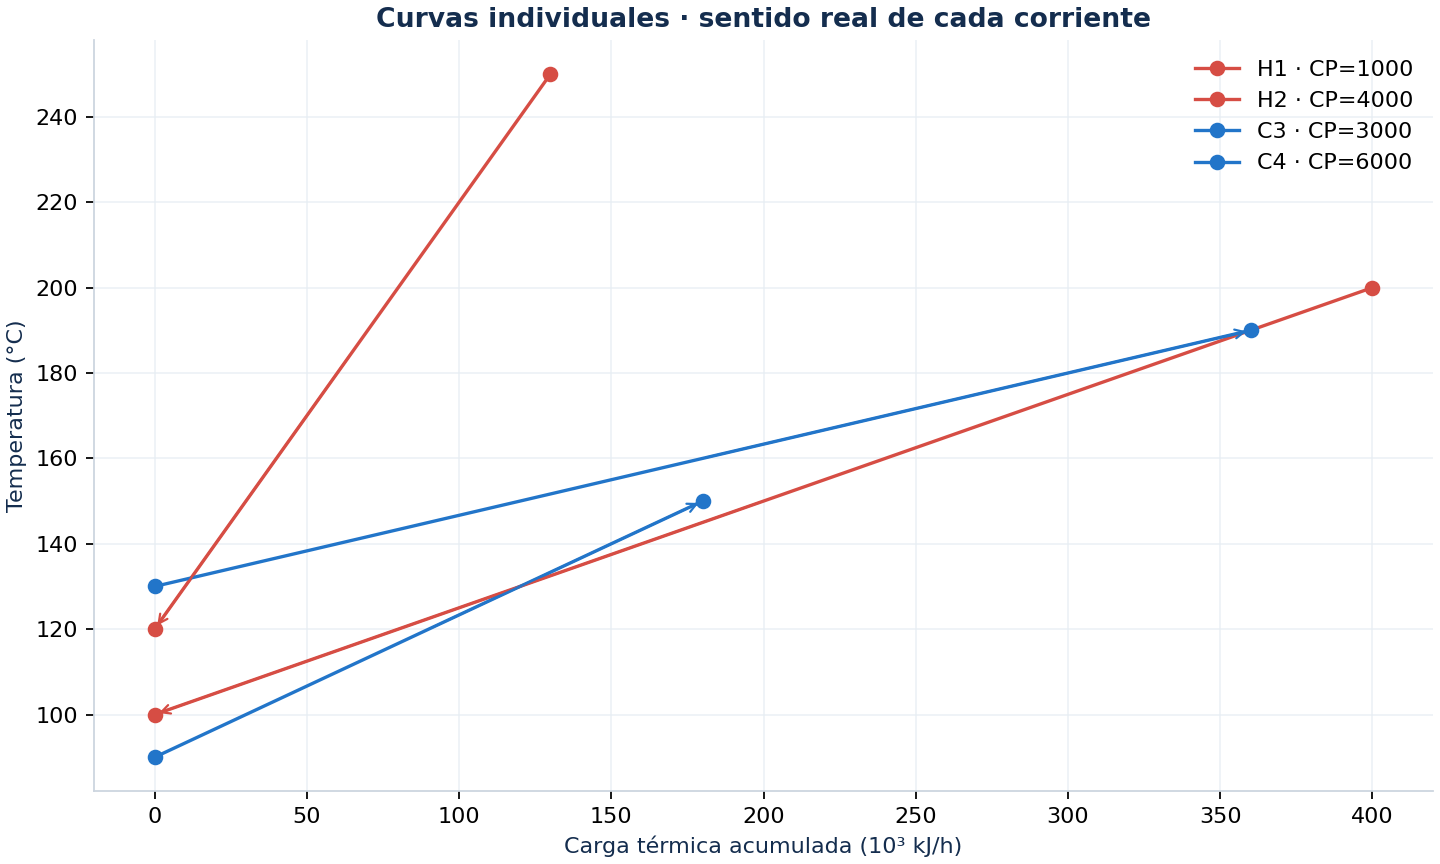

In [6]:
display(Image(filename=str(carpeta_resultados / '01_individuales.png'), width=900))

### Compuestas originales
Ambas compuestas parten de H = 0; todavía no representan el acoplamiento ajustado.

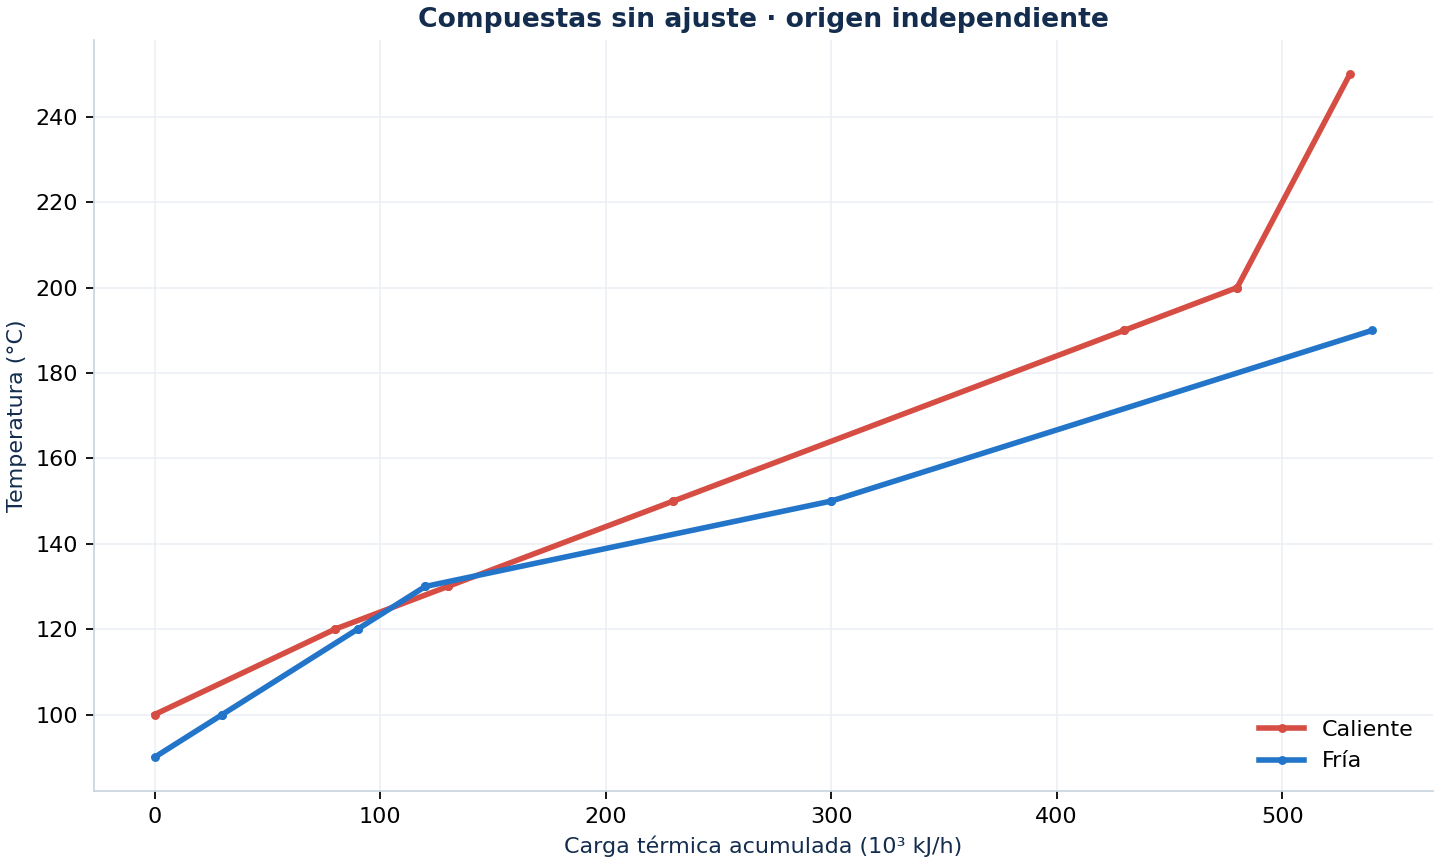

In [7]:
display(Image(filename=str(carpeta_resultados / '02_compuestas_originales.png'), width=900))

### Compuestas ajustadas
El solapamiento de entalpía corresponde al calor recuperable; las colas corresponden a los servicios.

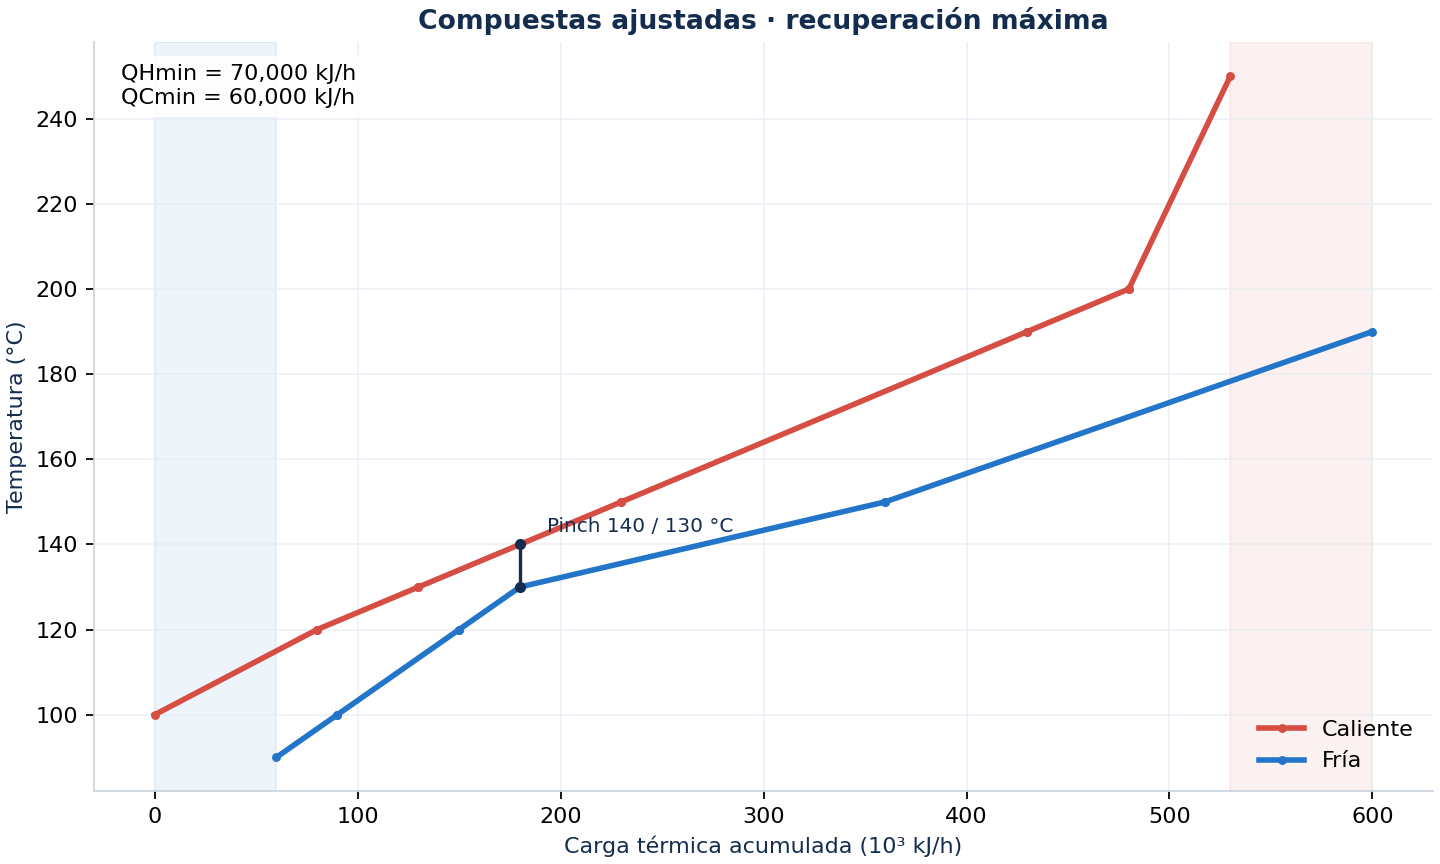

In [8]:
display(Image(filename=str(carpeta_resultados / '03_compuestas_ajustadas.png'), width=900))

### Compuestas con temperaturas desplazadas
Las calientes se desplazan −ΔT mínimo/2 y las frías +ΔT mínimo/2.

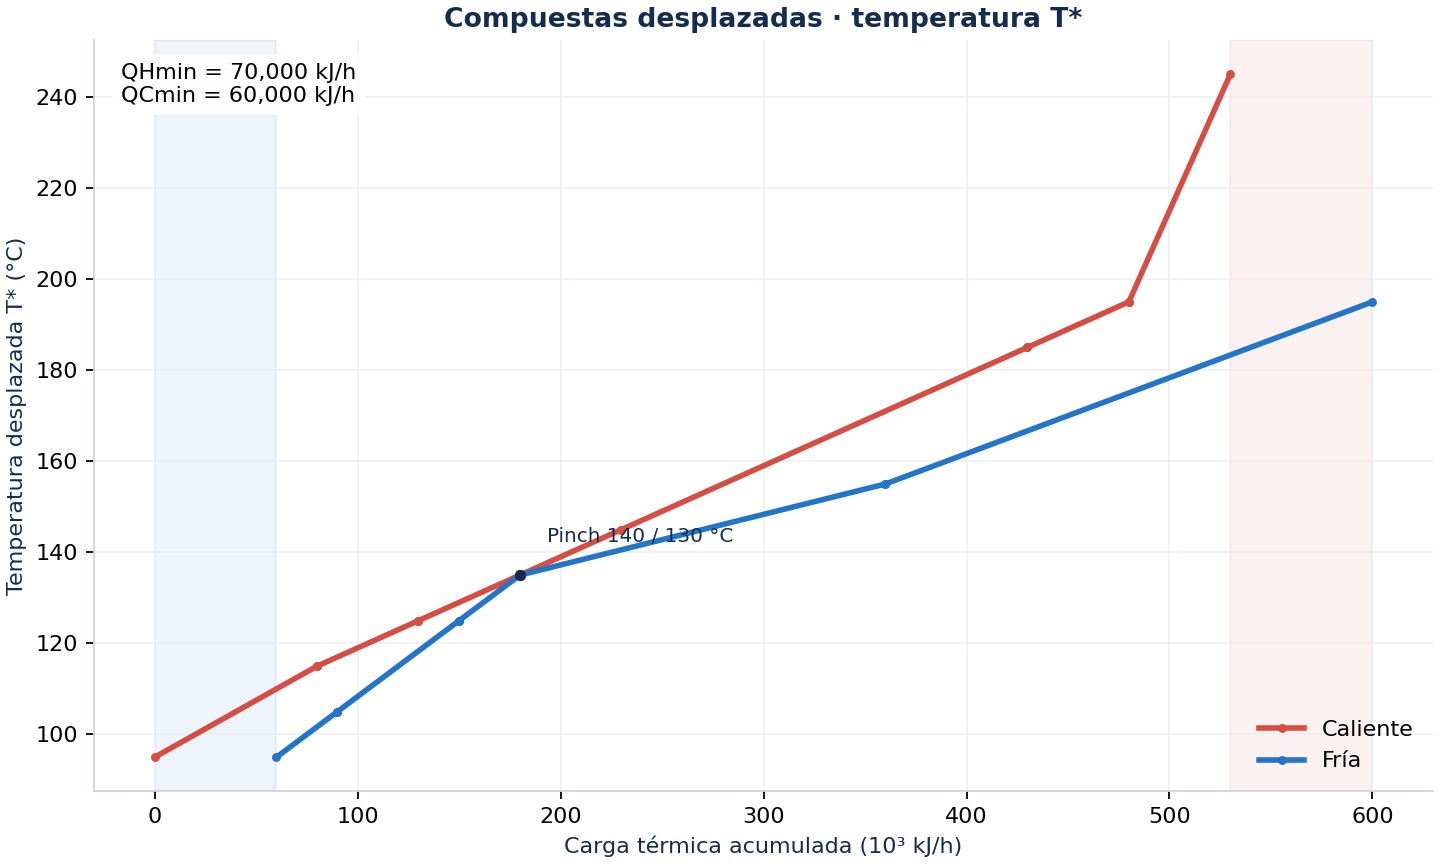

In [9]:
display(Image(filename=str(carpeta_resultados / '04_compuestas_desplazadas.png'), width=900))

### Gran curva compuesta
Representa el residual de la cascada frente a la temperatura desplazada.

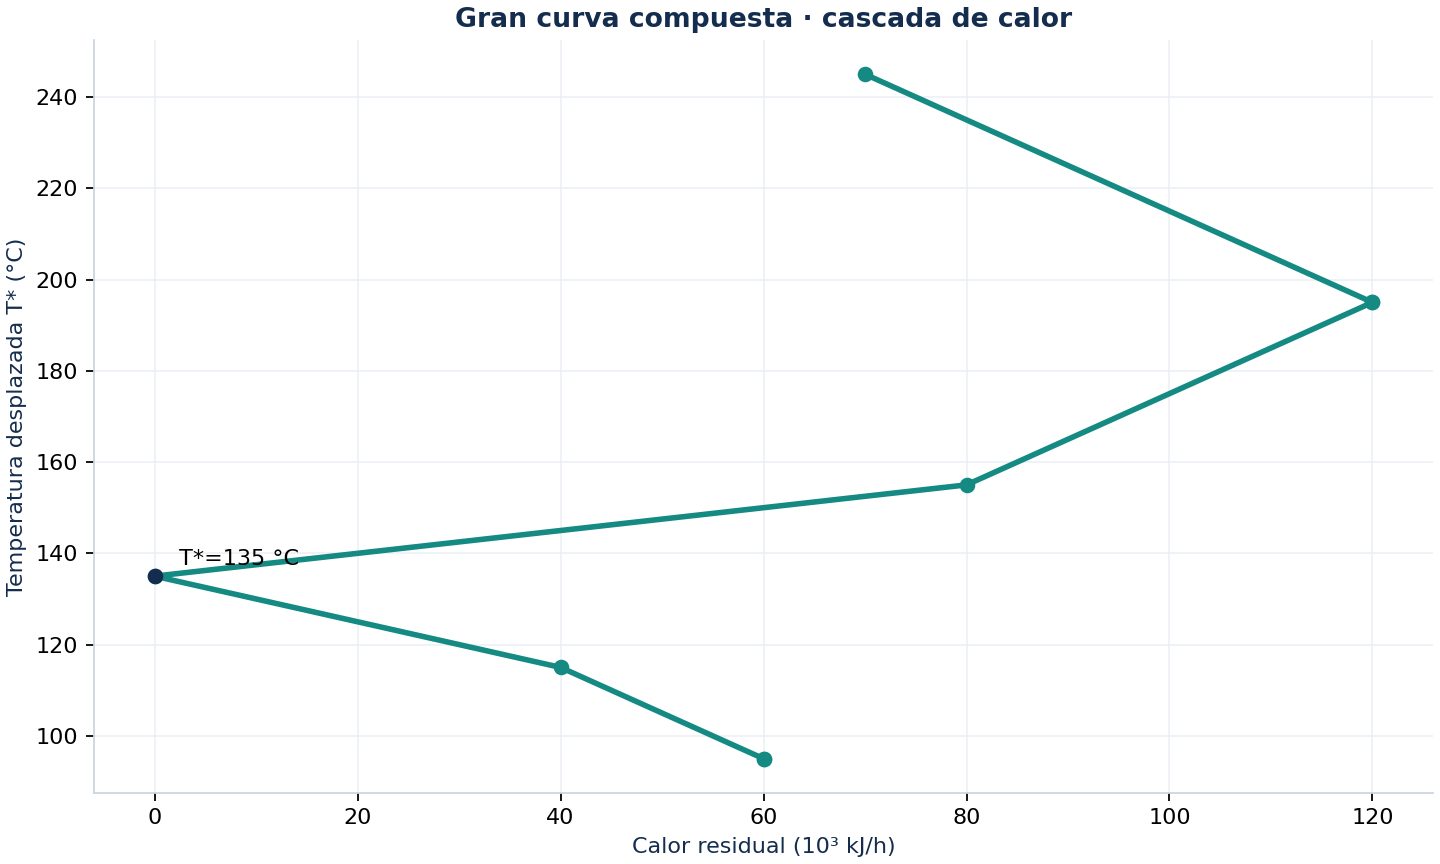

In [10]:
display(Image(filename=str(carpeta_resultados / '05_gran_compuesta.png'), width=900))

### Temperaturas de las corrientes
Muestra los intervalos térmicos recorridos por las corrientes.

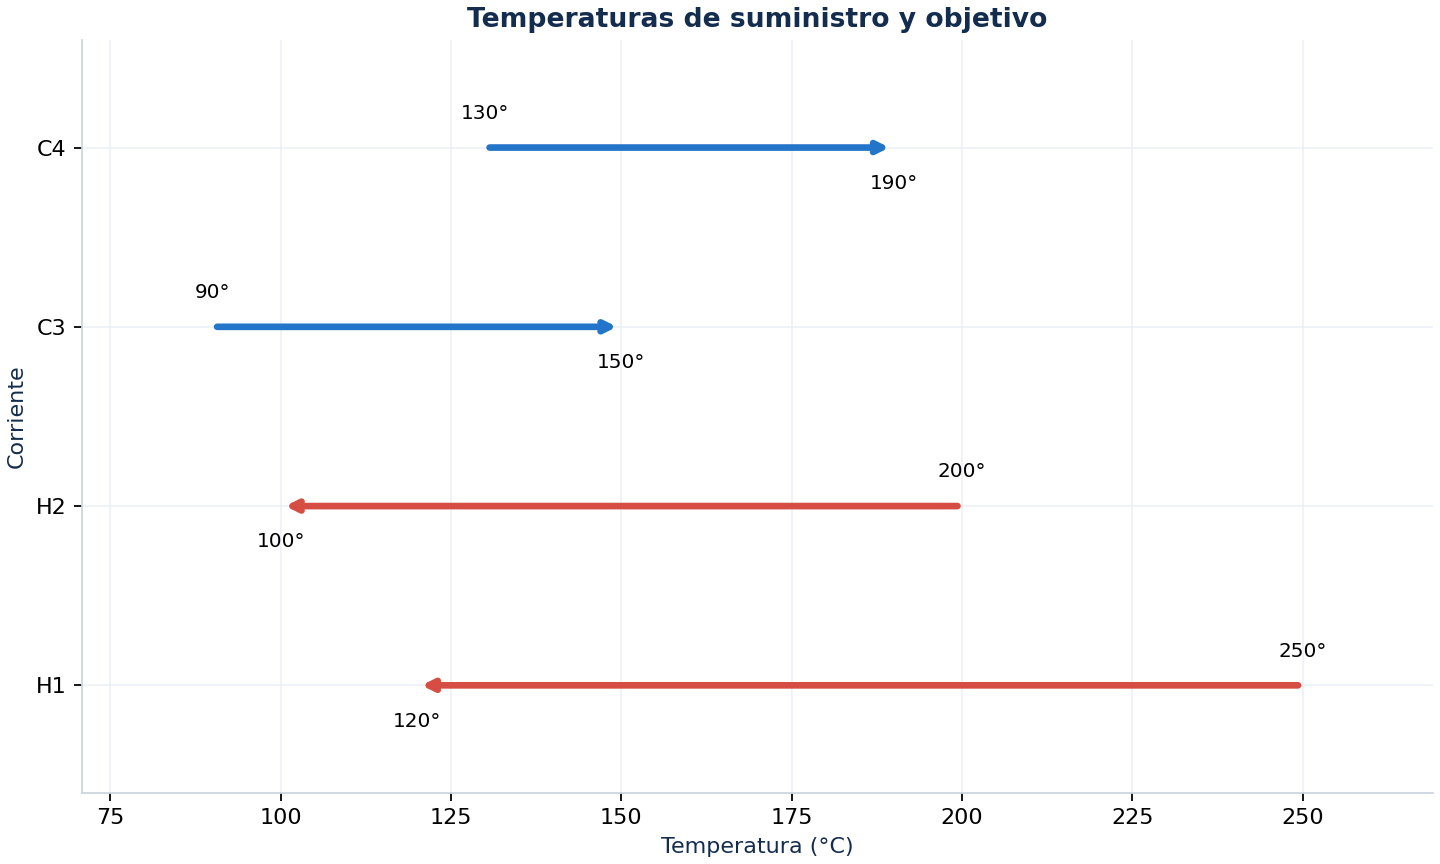

In [11]:
display(Image(filename=str(carpeta_resultados / '06_temperaturas.png'), width=900))

### Sensibilidad a ΔT mínimo
Repite el cálculo de servicios para diferentes valores de ΔT mínimo.

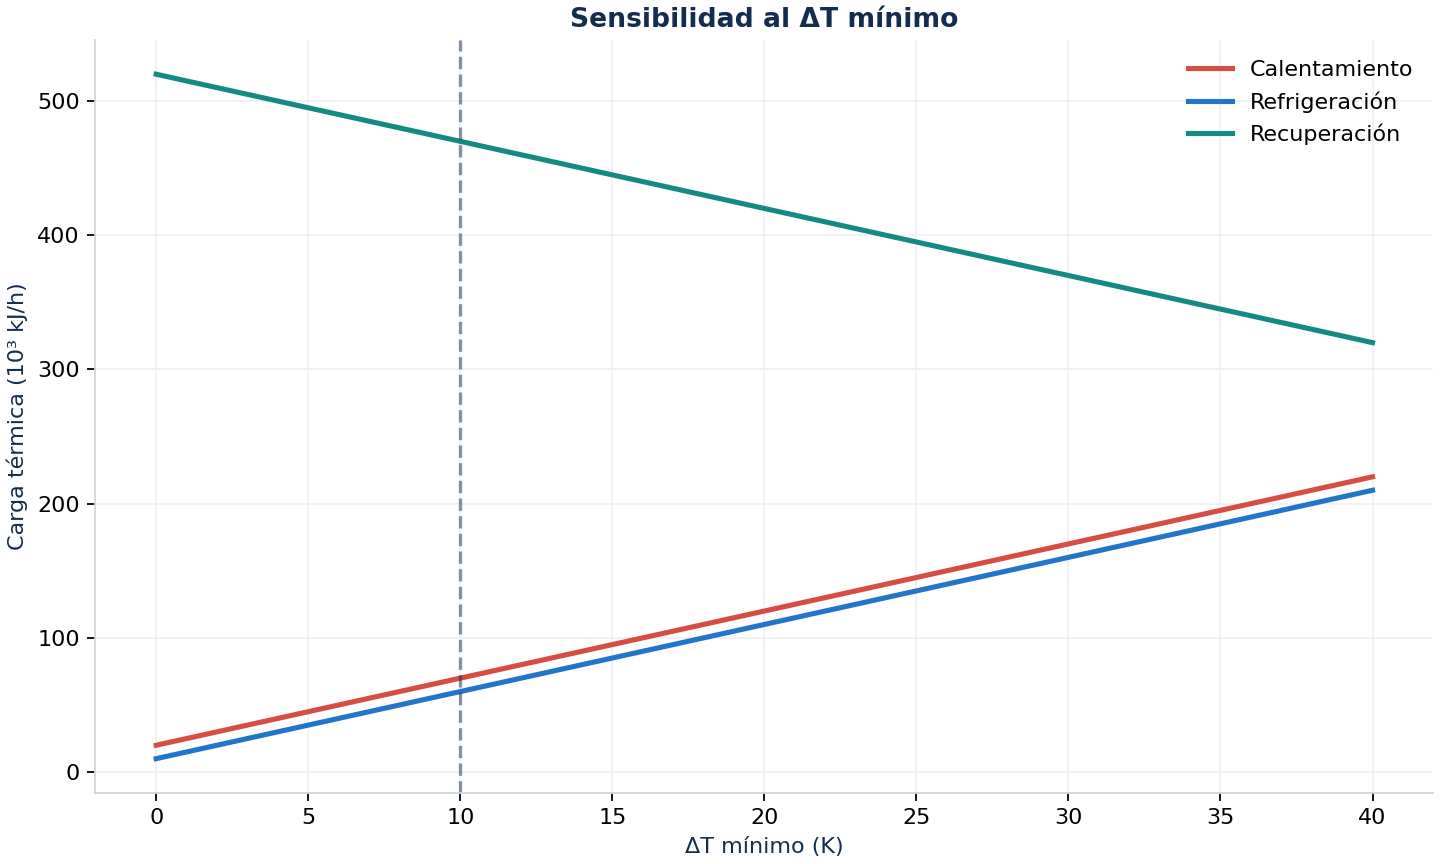

In [12]:
display(Image(filename=str(carpeta_resultados / '07_sensibilidad.png'), width=900))

### Matriz de intercambios
Cargas agregadas entre parejas de corrientes.

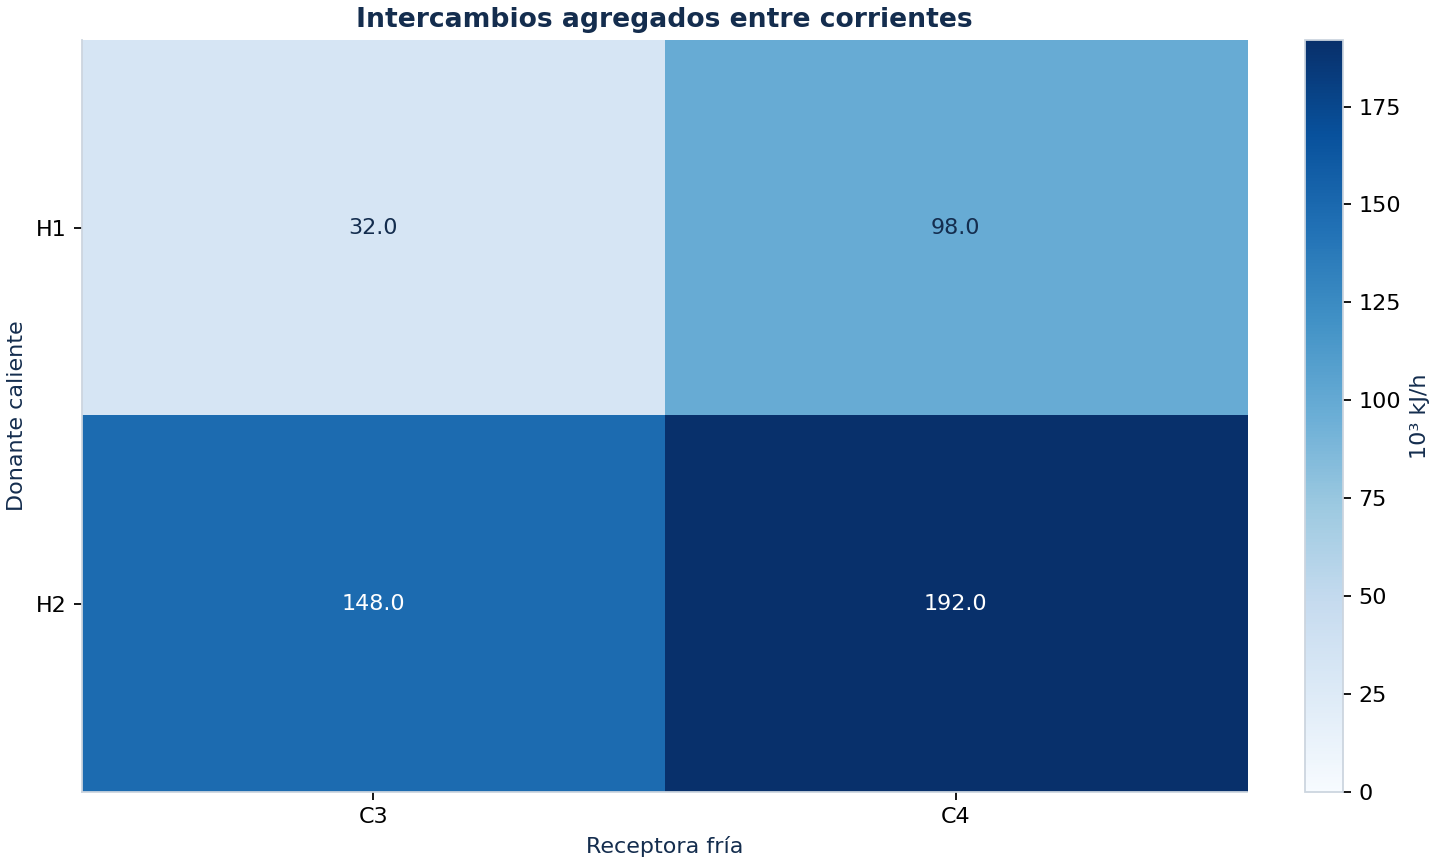

In [13]:
display(Image(filename=str(carpeta_resultados / '08_matriz_intercambios.png'), width=900))

### Red por tramos
Cada conexión corresponde a un equipo de ramas. Consulta fracciones y temperaturas en las tablas.

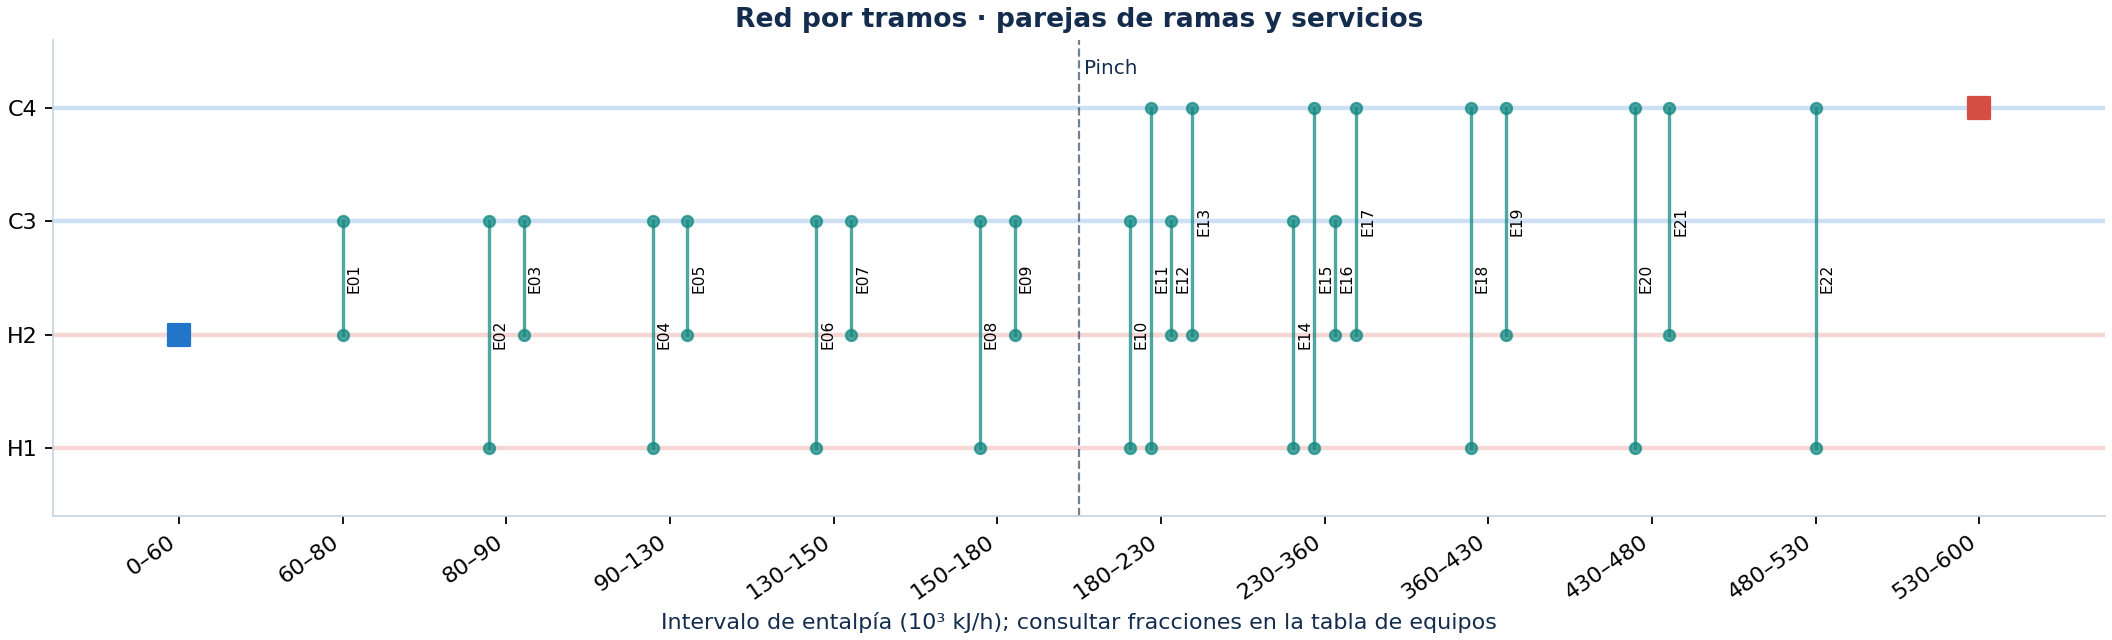

In [14]:
display(Image(filename=str(carpeta_resultados / '09_red_por_tramos.png'), width=900))

## 5. Descargar Excel y resultados
Selecciona `excel`, `zip` o `ninguno` y ejecuta esta celda con el botón ▶.
La opción `zip` incluye Excel, tablas CSV, gráficos PNG/SVG y resumen JSON.

En Excel puedes editar temperaturas, CP y ΔT mínimo en **Entradas**.
Para cambiar el número de corrientes, cambia este cuaderno y genera otro libro.

In [ ]:
#@title Descargar resultados
descarga = "excel" #@param ["excel", "zip", "ninguno"]
import shutil
if descarga == 'zip':
    archivo = Path(shutil.make_archive(str(carpeta_programa / 'Pinch_Resultados'), 'zip', carpeta_resultados))
elif descarga == 'excel':
    archivo = carpeta_resultados / 'Pinch_Analisis.xlsx'
elif descarga == 'ninguno':
    archivo = None
else:
    raise ValueError('Selecciona excel, zip o ninguno.')
if archivo is not None:
    try:
        from google.colab import files
    except ImportError:
        # Fuera de Colab, Jupyter muestra un enlace al archivo generado.
        display(FileLink(str(archivo.relative_to(Path.cwd()))))
    else:
        files.download(str(archivo))

/workspace/scratch/96ad63a0357a/tmp/colab_validation/pinch_lab_colab/resultados/Pinch_Analisis.xlsx

## Método, fuentes y alcance

Se utiliza el código de Pinch Lab entregado junto al ejercicio de las diapositivas
26–30 del PDF aportado: `P2_260921_Energy_Integration_Pinch_Analysis_V1_Lluis_26_27 (1).pdf`.
Los datos de las cuatro corrientes y ΔT mínimo inicial están explícitos en el apartado 2.
Este archivo funciona sin acceso al PDF ni al repositorio de GitHub.

El modelo supone régimen estacionario, CP constante, calor sensible y ausencia
de pérdidas. La red permite dividir y recombinar cada corriente. Alcanza los
servicios mínimos del modelo; **no optimiza el número de equipos ni sus costes**.
No incluye calor latente, restricciones de contacto ni selección de temperaturas
para las utilidades. `U=0` significa área no calculada.

La preparación de módulos reproduce exactamente `pinch.py`, `excel_export.py`
y las pruebas del proyecto entregado. Este cuaderno se ha ejecutado de principio
a fin con IPython para comprobar cálculos, tablas, generación de archivos
y figuras. La subida y descarga mediante la interfaz real de Google Colab requieren
la sesión del usuario y no se han probado en ella.

Documentación de Colab: <https://research.google.com/colaboratory/faq.html>.